# Eye Movement-Based Schizophrenia Recognition
## Diagnostic Visualization & Scientific Analysis — Current Results

Generates all figures for the 5-Tier Hierarchical Framework paper.  
**Run cells in order.** All figures are saved to `results/` and `experiments/ablation/figures/`.

| Section | Content |
|---|---|
| 1 | EDA & Preprocessing (Tier 1) |
| 2 | Feature Engineering (Tier 2) |
| 3 | Tabular Baselines + SHAP (Tier 3) |
| 4 | Deep Sequential Models — Category & Attention (Tier 4) |
| 5 | Ensemble, Calibration & SOTA Comparison (Tier 5) |
| 6 | Individual Patient Case Study: SZ vs HC |
| 7 | Model Explainability for Individual Predictions |

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    roc_curve, auc as sk_auc, roc_auc_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 150,
})
sns.set_style('whitegrid')

# ── Google Colab Detection & Drive Mount ─────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition')
    print('Running on Google Colab. Project root:', PROJECT_ROOT)
else:
    PROJECT_ROOT = Path(os.getcwd())
    if not (PROJECT_ROOT / 'results').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    print('Running locally. Project root:', PROJECT_ROOT)

assert (PROJECT_ROOT / 'results').exists(), (
    f'Cannot find results/ at {PROJECT_ROOT}. '
    'Check that the Drive path matches your folder name exactly.'
)

RES = PROJECT_ROOT / 'results'
ABL = PROJECT_ROOT / 'experiments' / 'ablation' / 'figures'

for d in [RES, ABL, RES / 'tier5_bica_s42' / 'figures']:
    d.mkdir(parents=True, exist_ok=True)

# ── Color Palette ─────────────────────────────────────────────────────────────
C_HC, C_SZ     = '#2196F3', '#F44336'
C_SOTA         = '#607D8B'
C_XGB, C_CAT   = '#8BC34A', '#4CAF50'
C_STGNN        = '#FF9800'
C_CEFAM        = '#FF5722'
C_BICA         = '#9C27B0'
C_T5           = '#E91E63'

SEEDS           = ['s42', 's123', 's456']
SCREEN_W        = 1024
SCREEN_H        = 768
DUR_THRESH      = 50
SOTA_AUC        = 0.8854
SOTA_ACC        = 0.8125

STIM_FEAT_COLS = [
    'fix_count', 'fix_dur_mean', 'fix_dur_median', 'fix_dur_std',
    'sacc_amp_mean', 'sacc_amp_std', 'sa_fdr_mean', 'sacc_angle_mean',
    'scanpath_length', 'convex_hull_area', 'center_bias',
    'spatial_entropy', 'pupil_mean', 'pupil_std', 'pupil_cv'
]
FEAT_LABELS = {
    'fix_count':'Fix. Count', 'fix_dur_mean':'Fix. Dur. Mean (ms)',
    'fix_dur_median':'Fix. Dur. Median (ms)', 'fix_dur_std':'Fix. Dur. Std (ms)',
    'sacc_amp_mean':'Sacc. Amp. Mean (px)', 'sacc_amp_std':'Sacc. Amp. Std (px)',
    'sa_fdr_mean':'SA-FDR Mean', 'sacc_angle_mean':'Sacc. Angle (rad)',
    'scanpath_length':'Scanpath Length (px)', 'convex_hull_area':'Conv. Hull Area',
    'center_bias':'Center Bias (px)', 'spatial_entropy':'Spatial Entropy',
    'pupil_mean':'Pupil Mean', 'pupil_std':'Pupil Std', 'pupil_cv':'Pupil CV',
}

print('Setup complete.')
print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'results/     : {RES}')
print(f'ablation/    : {ABL}')

Mounted at /content/drive
Running on Google Colab. Project root: /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition
Setup complete.
PROJECT_ROOT : /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition
results/     : /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition/results
ablation/    : /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition/experiments/ablation/figures


In [10]:
# ── Load Processed Data ───────────────────────────────────────────────────────
df_clean = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'clean_fixations.parquet')
df_stim  = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'features_stimulus_level.csv')
df_subj  = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'features_subject_level.csv')

# Labeled training subjects only (exclude 48 unlabeled test subjects)
df_tr = df_clean[(df_clean['Is_Test']==0) & (df_clean['Label'].isin([0,1]))].copy()
df_st = df_stim [(df_stim ['Is_Test']==0) & (df_stim ['Label'].isin([0,1]))].copy()
df_sj = df_subj [(df_subj ['Is_Test']==0) & (df_subj ['Label'].isin([0,1]))].copy()
df_st['Group'] = df_st['Label'].map({0:'HC',1:'SZ'})
df_sj['Group'] = df_sj['Label'].map({0:'HC',1:'SZ'})

df_hc = df_tr[df_tr['Label']==0]
df_sz = df_tr[df_tr['Label']==1]

print(f'Training subjects : {len(df_sj)} (SZ={int((df_sj.Label==1).sum())}, HC={int((df_sj.Label==0).sum())})')
print(f'Training fixations: {len(df_tr):,}')
print(f'Stimulus trials   : {len(df_st):,}')
print(f'Subject-level cols: {df_sj.shape[1]}')
print(f'Stimulus-level cols: {df_st.shape[1]}')

Training subjects : 160 (SZ=80, HC=80)
Training fixations: 215,138
Stimulus trials   : 15,907
Subject-level cols: 124
Stimulus-level cols: 20


---
## Section 1 — EDA & Preprocessing (Tier 1)

- **Spatial filter**: removes fixations outside 1024×768 screen (1.71% removed)
- **Temporal filter**: removes micro-fixations < 50 ms (2.66% removed)
- **Pupil dynamics**: preserved from raw Excel export; SZ patients show significantly lower, more variable pupil diameter (*p* < 0.001)

Dataset: **160 labeled subjects** (80 SZ / 80 HC), Tobii T60 60 Hz eye tracker, 100 stimuli × 4 categories (Social, Natural, Manipulated, Synthetic), plus **48 unlabeled test subjects**.

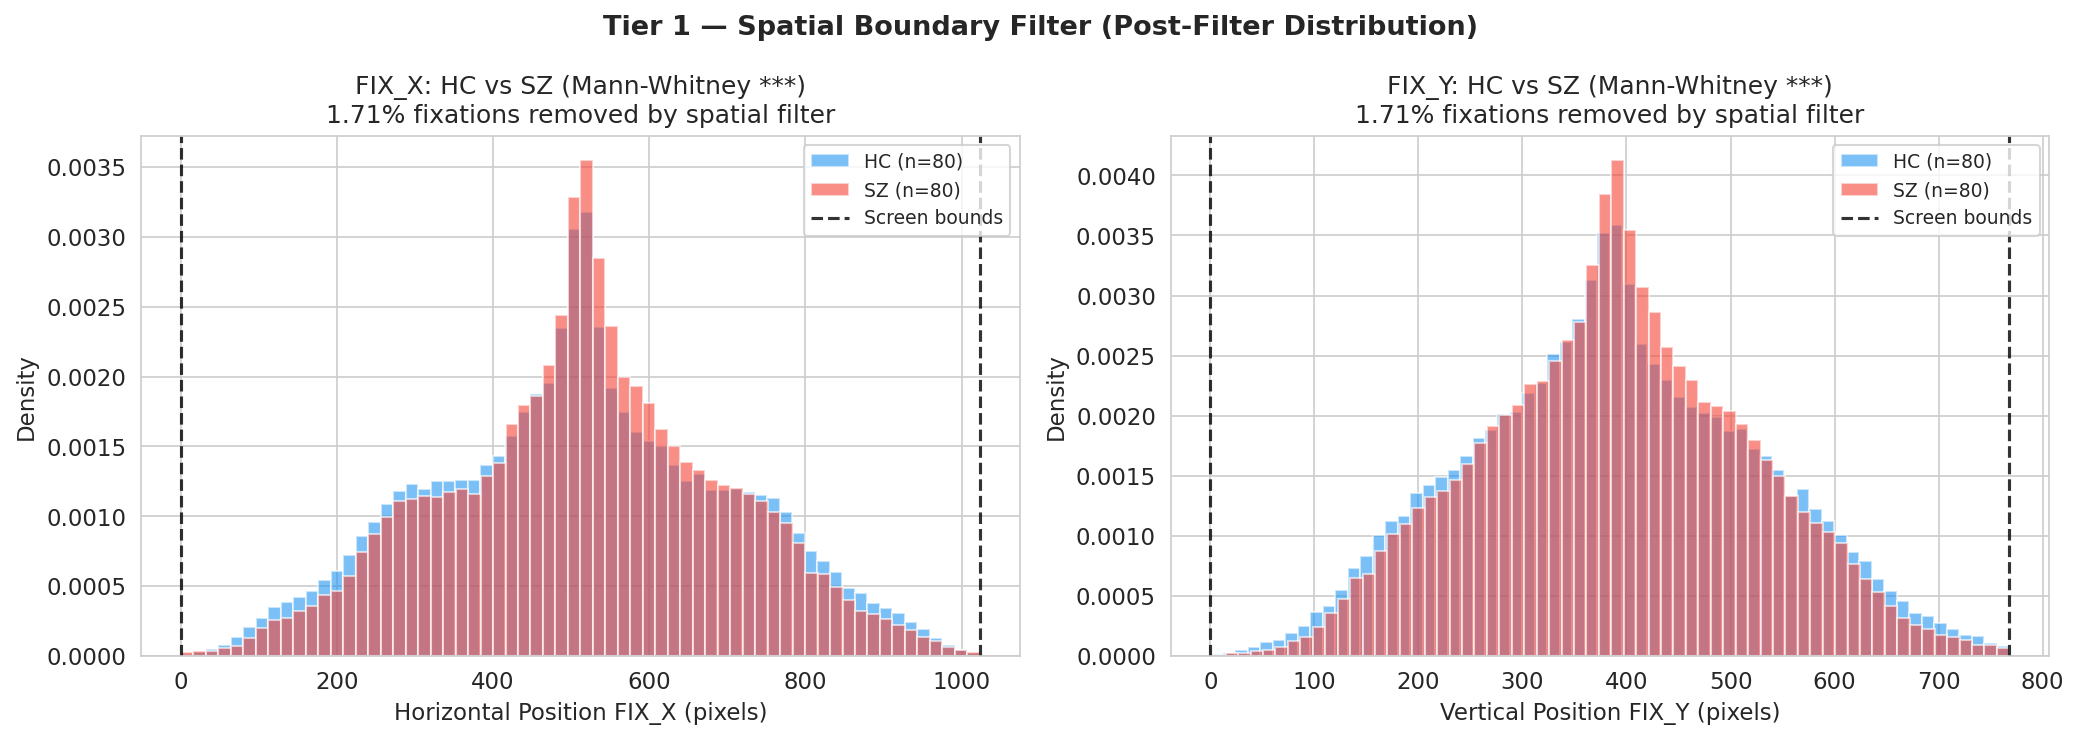

Saved: tier1_spatial_filter.png


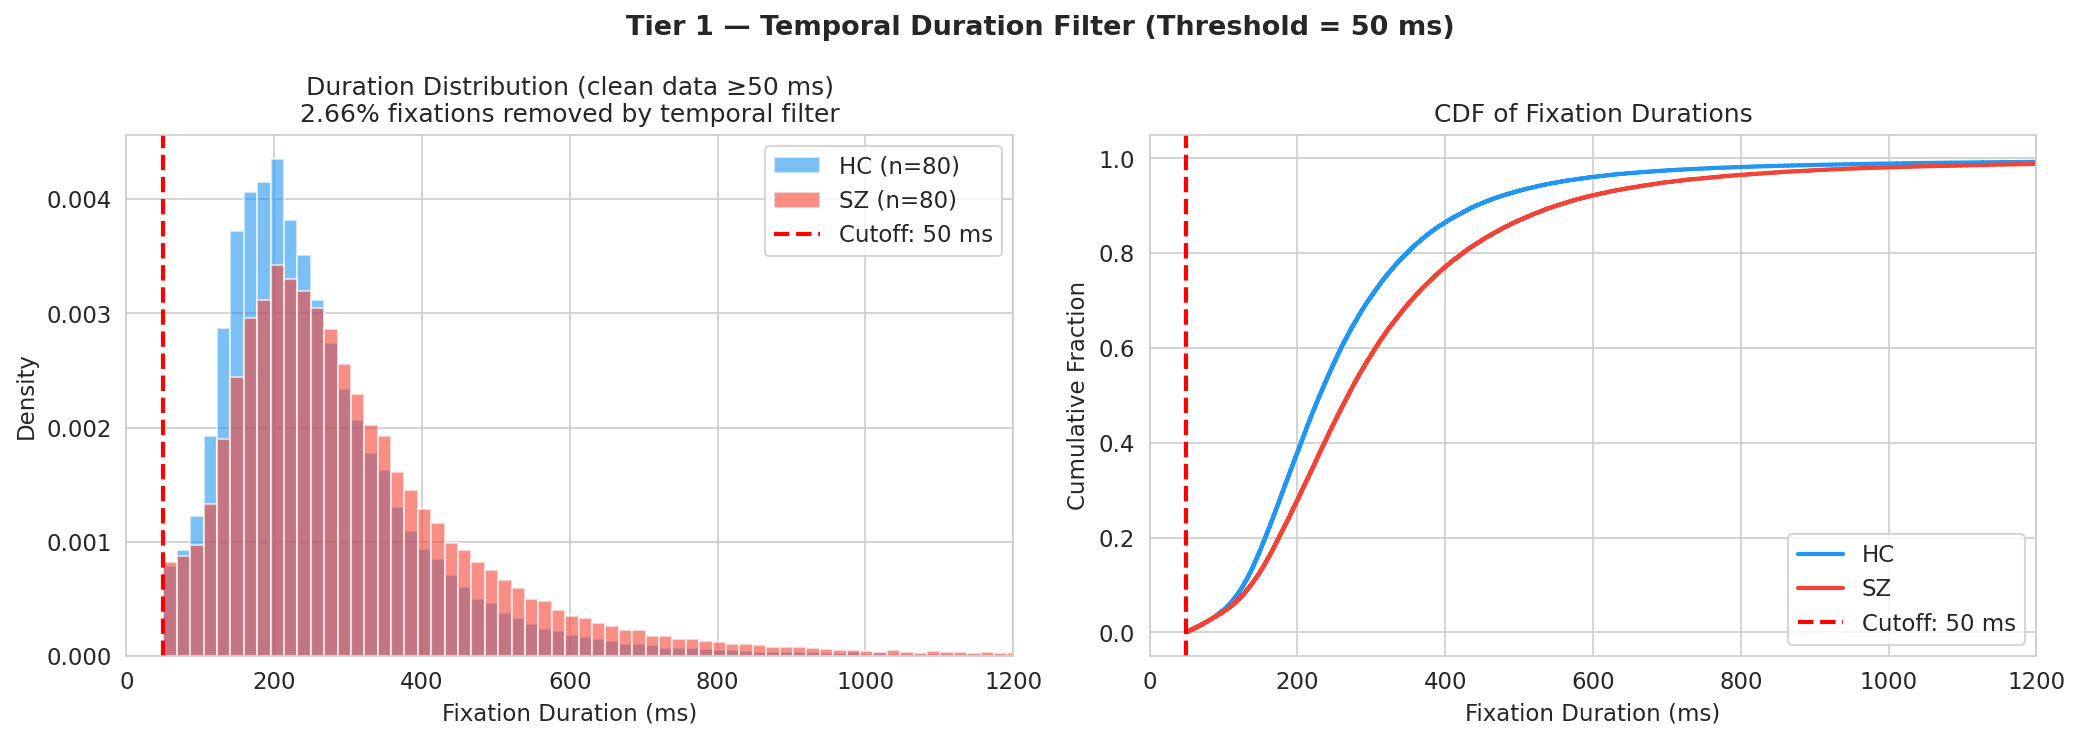

Saved: tier1_temporal_filter.png


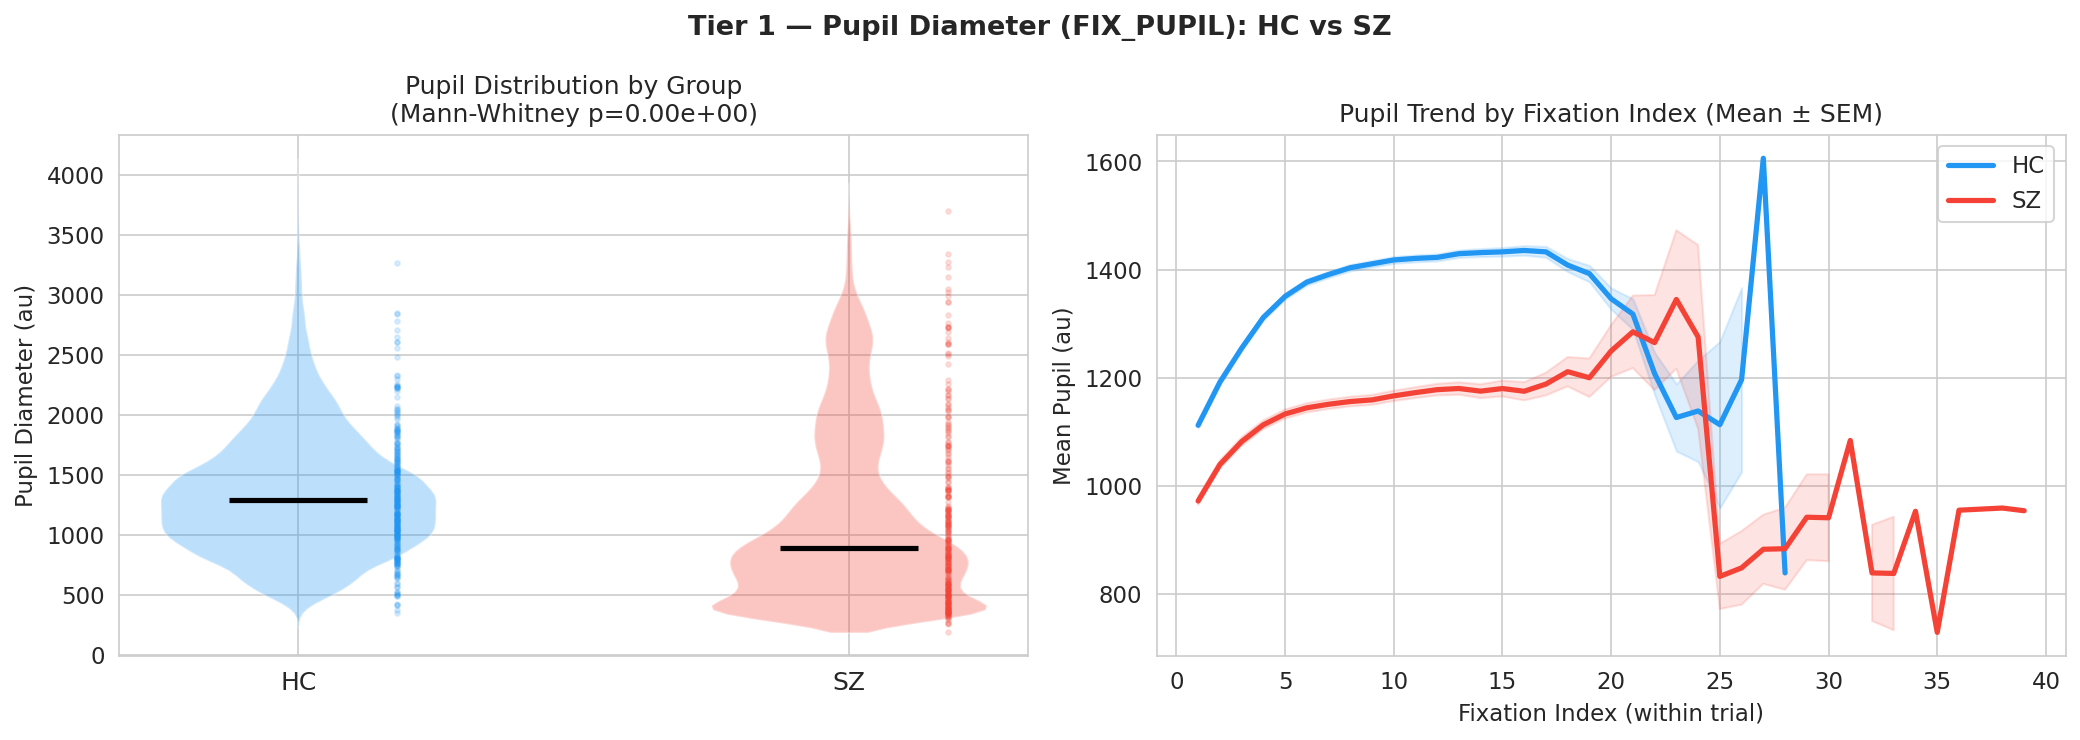

Saved: tier1_pupil_dynamics.png


In [11]:
# ── Section 1: Preprocessing Visualizations ─────────────────────────────────

# 1A: Spatial Filter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tier 1 — Spatial Boundary Filter (Post-Filter Distribution)', fontweight='bold', fontsize=13)
for ax, col, xhi, xlabel in [
    (axes[0], 'FIX_X', SCREEN_W, 'Horizontal Position FIX_X (pixels)'),
    (axes[1], 'FIX_Y', SCREEN_H, 'Vertical Position FIX_Y (pixels)'),
]:
    ax.hist(df_hc[col], bins=64, alpha=0.6, color=C_HC, density=True, label='HC (n=80)')
    ax.hist(df_sz[col], bins=64, alpha=0.6, color=C_SZ, density=True, label='SZ (n=80)')
    ax.axvline(0,   color='k', ls='--', lw=1.5, alpha=0.8, label='Screen bounds')
    ax.axvline(xhi, color='k', ls='--', lw=1.5, alpha=0.8)
    u, p = stats.mannwhitneyu(df_hc[col].dropna(), df_sz[col].dropna())
    stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(f'{col}: HC vs SZ (Mann-Whitney {stars})\n1.71% fixations removed by spatial filter')
    ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(RES / 'tier1_spatial_filter.png', bbox_inches='tight')
plt.show(); print('Saved: tier1_spatial_filter.png')

# 1B: Temporal Filter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tier 1 — Temporal Duration Filter (Threshold = 50 ms)', fontweight='bold', fontsize=13)
ax = axes[0]
for grp, col, lbl in [(df_hc, C_HC,'HC (n=80)'), (df_sz, C_SZ,'SZ (n=80)')]:
    ax.hist(grp['FIX_DURATION'].clip(upper=1500), bins=80, alpha=0.6,
            color=col, density=True, label=lbl)
ax.axvline(DUR_THRESH, color='red', ls='--', lw=2, label=f'Cutoff: {DUR_THRESH} ms')
ax.set_xlabel('Fixation Duration (ms)'); ax.set_ylabel('Density')
ax.set_title('Duration Distribution (clean data ≥50 ms)\n2.66% fixations removed by temporal filter')
ax.legend(); ax.set_xlim(0, 1200)
ax = axes[1]
for grp, col, lbl in [(df_hc, C_HC,'HC'), (df_sz, C_SZ,'SZ')]:
    s = np.sort(grp['FIX_DURATION'].values)
    ax.plot(s, np.arange(len(s))/len(s), color=col, lw=2, label=lbl)
ax.axvline(DUR_THRESH, color='red', ls='--', lw=2, label=f'Cutoff: {DUR_THRESH} ms')
ax.set_xlabel('Fixation Duration (ms)'); ax.set_ylabel('Cumulative Fraction')
ax.set_title('CDF of Fixation Durations'); ax.legend(); ax.set_xlim(0, 1200)
fig.tight_layout()
fig.savefig(RES / 'tier1_temporal_filter.png', bbox_inches='tight')
plt.show(); print('Saved: tier1_temporal_filter.png')

# 1C: Pupil Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tier 1 — Pupil Diameter (FIX_PUPIL): HC vs SZ', fontweight='bold', fontsize=13)
ax = axes[0]
data_hc = df_hc['FIX_PUPIL'].dropna().values
data_sz = df_sz['FIX_PUPIL'].dropna().values
vp = ax.violinplot([data_hc, data_sz], positions=[1,2], showmedians=True, showextrema=False)
vp['bodies'][0].set_facecolor(C_HC); vp['bodies'][1].set_facecolor(C_SZ)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2.5)
rng = np.random.default_rng(42)
for pos, arr, c in [(1.18, data_hc, C_HC), (2.18, data_sz, C_SZ)]:
    samp = rng.choice(arr, min(300, len(arr)), replace=False)
    ax.scatter([pos]*len(samp), samp, alpha=0.15, s=5, color=c)
ax.set_xticks([1,2]); ax.set_xticklabels(['HC','SZ'], fontsize=12)
u, p = stats.mannwhitneyu(data_hc, data_sz)
ax.set_ylabel('Pupil Diameter (au)')
ax.set_title(f'Pupil Distribution by Group\n(Mann-Whitney p={p:.2e})')
ax = axes[1]
df_tr2 = df_tr.copy()
df_tr2['fix_idx_c'] = df_tr2['FIX_INDEX'].clip(upper=50)
pidx = df_tr2.groupby(['fix_idx_c','Label'])['FIX_PUPIL'].agg(['mean','sem']).reset_index()
for lbl, col, nm in [(0,C_HC,'HC'),(1,C_SZ,'SZ')]:
    s = pidx[pidx['Label']==lbl]
    ax.plot(s['fix_idx_c'], s['mean'], color=col, lw=2.5, label=nm)
    ax.fill_between(s['fix_idx_c'], s['mean']-s['sem'], s['mean']+s['sem'],
                    color=col, alpha=0.15)
ax.set_xlabel('Fixation Index (within trial)'); ax.set_ylabel('Mean Pupil (au)')
ax.set_title('Pupil Trend by Fixation Index (Mean \u00b1 SEM)'); ax.legend()
fig.tight_layout()
fig.savefig(RES / 'tier1_pupil_dynamics.png', bbox_inches='tight')
plt.show(); print('Saved: tier1_pupil_dynamics.png')

---
## Section 2 — Feature Engineering (Tier 2)

**15 stimulus-level features** per trial → **135-dim expert vector** per subject:
- 60 category means (15 features × 4 stimulus categories)
- 60 delta features (15 features × 4 contrast pairs: Soc–Nat, Man–Nat, Soc–Syn, Man–Syn)

**SA-FDR** (Saccade Amplitude to next Fixation Duration Ratio): `SA-FDR_i = Amp_i / Dur_{i+1}` — a velocity proxy constrained by 60 Hz hardware (true saccade duration is unavailable at 60 Hz).

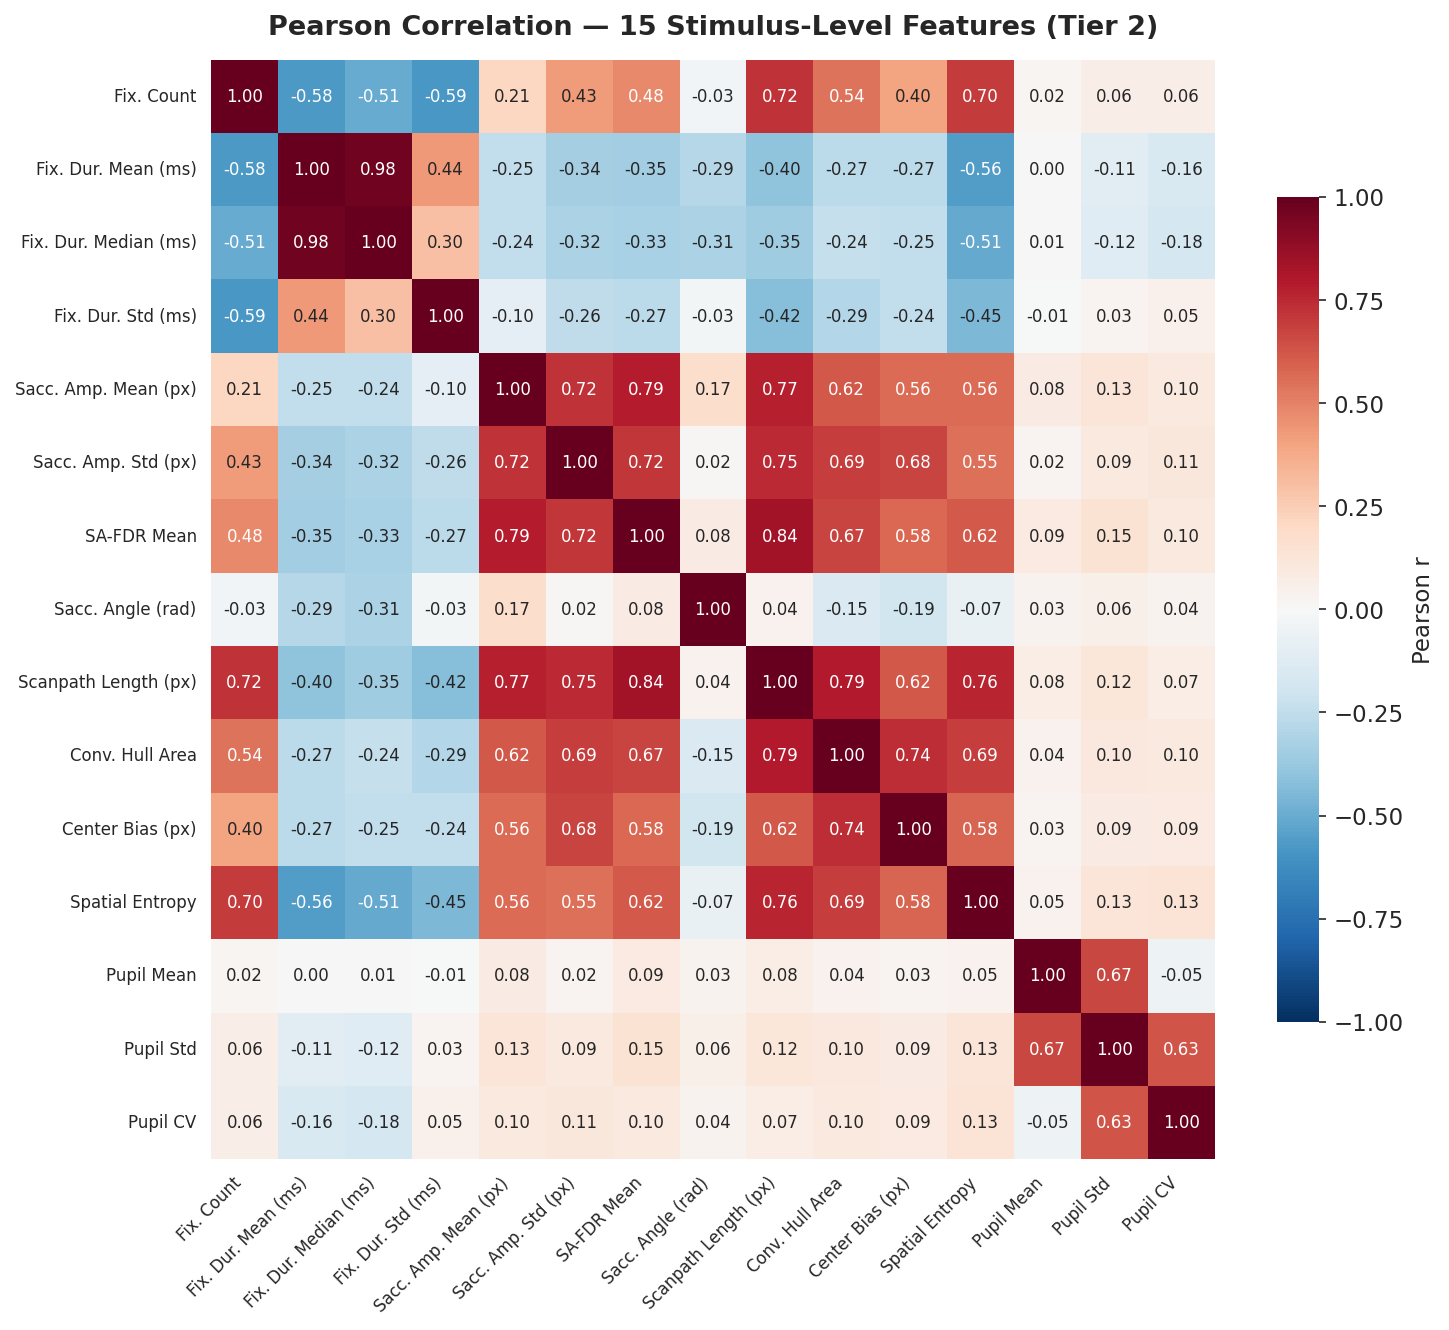

Saved: tier2_correlation_heatmap.png


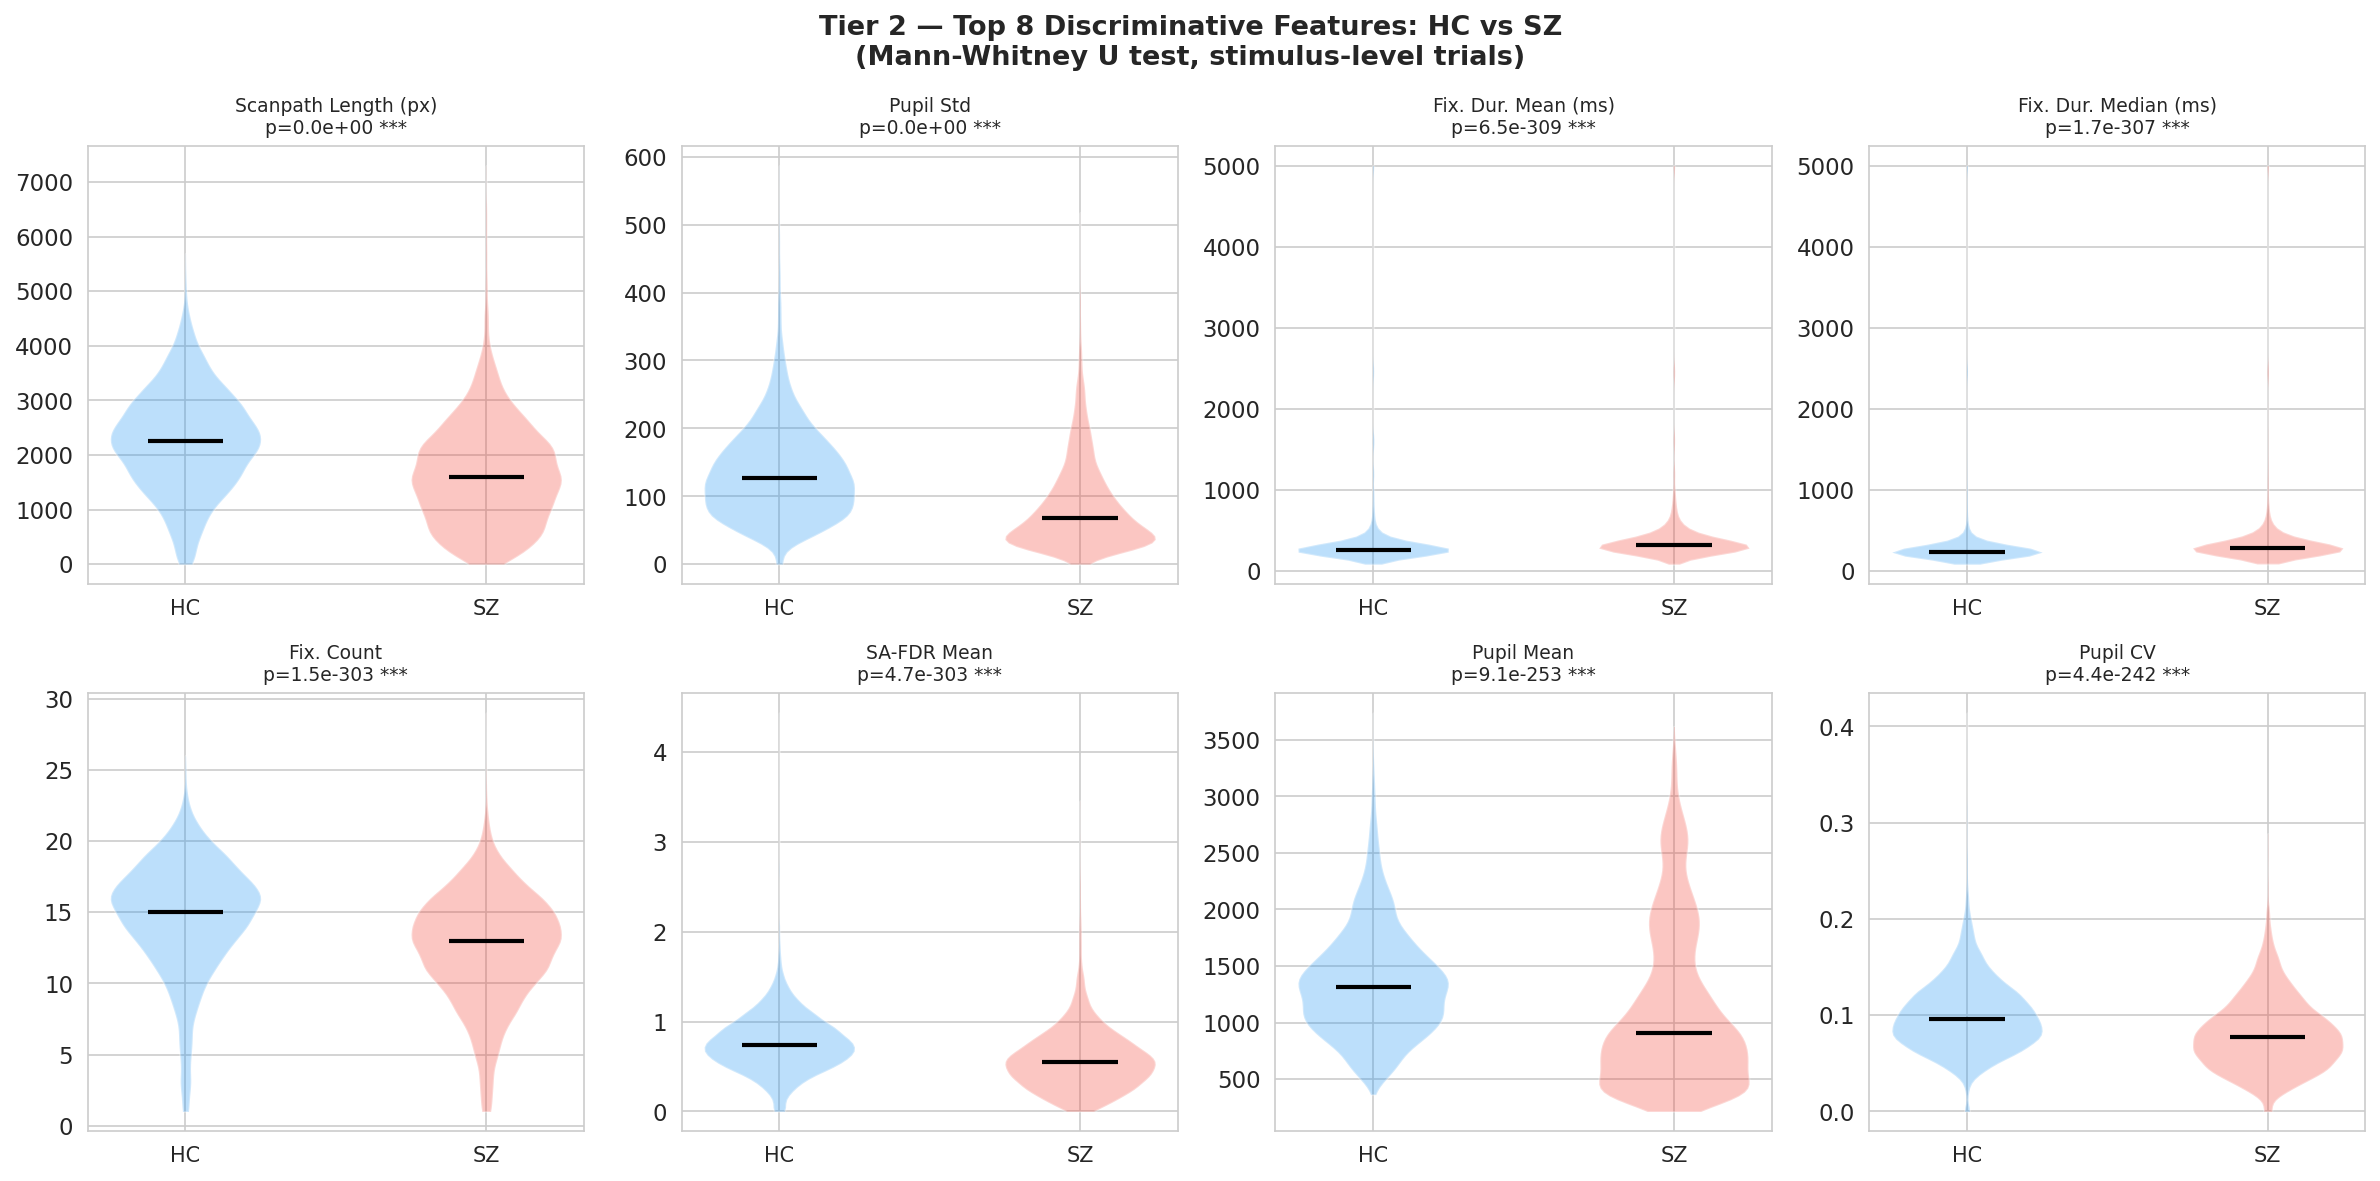

Saved: tier2_feature_violin.png


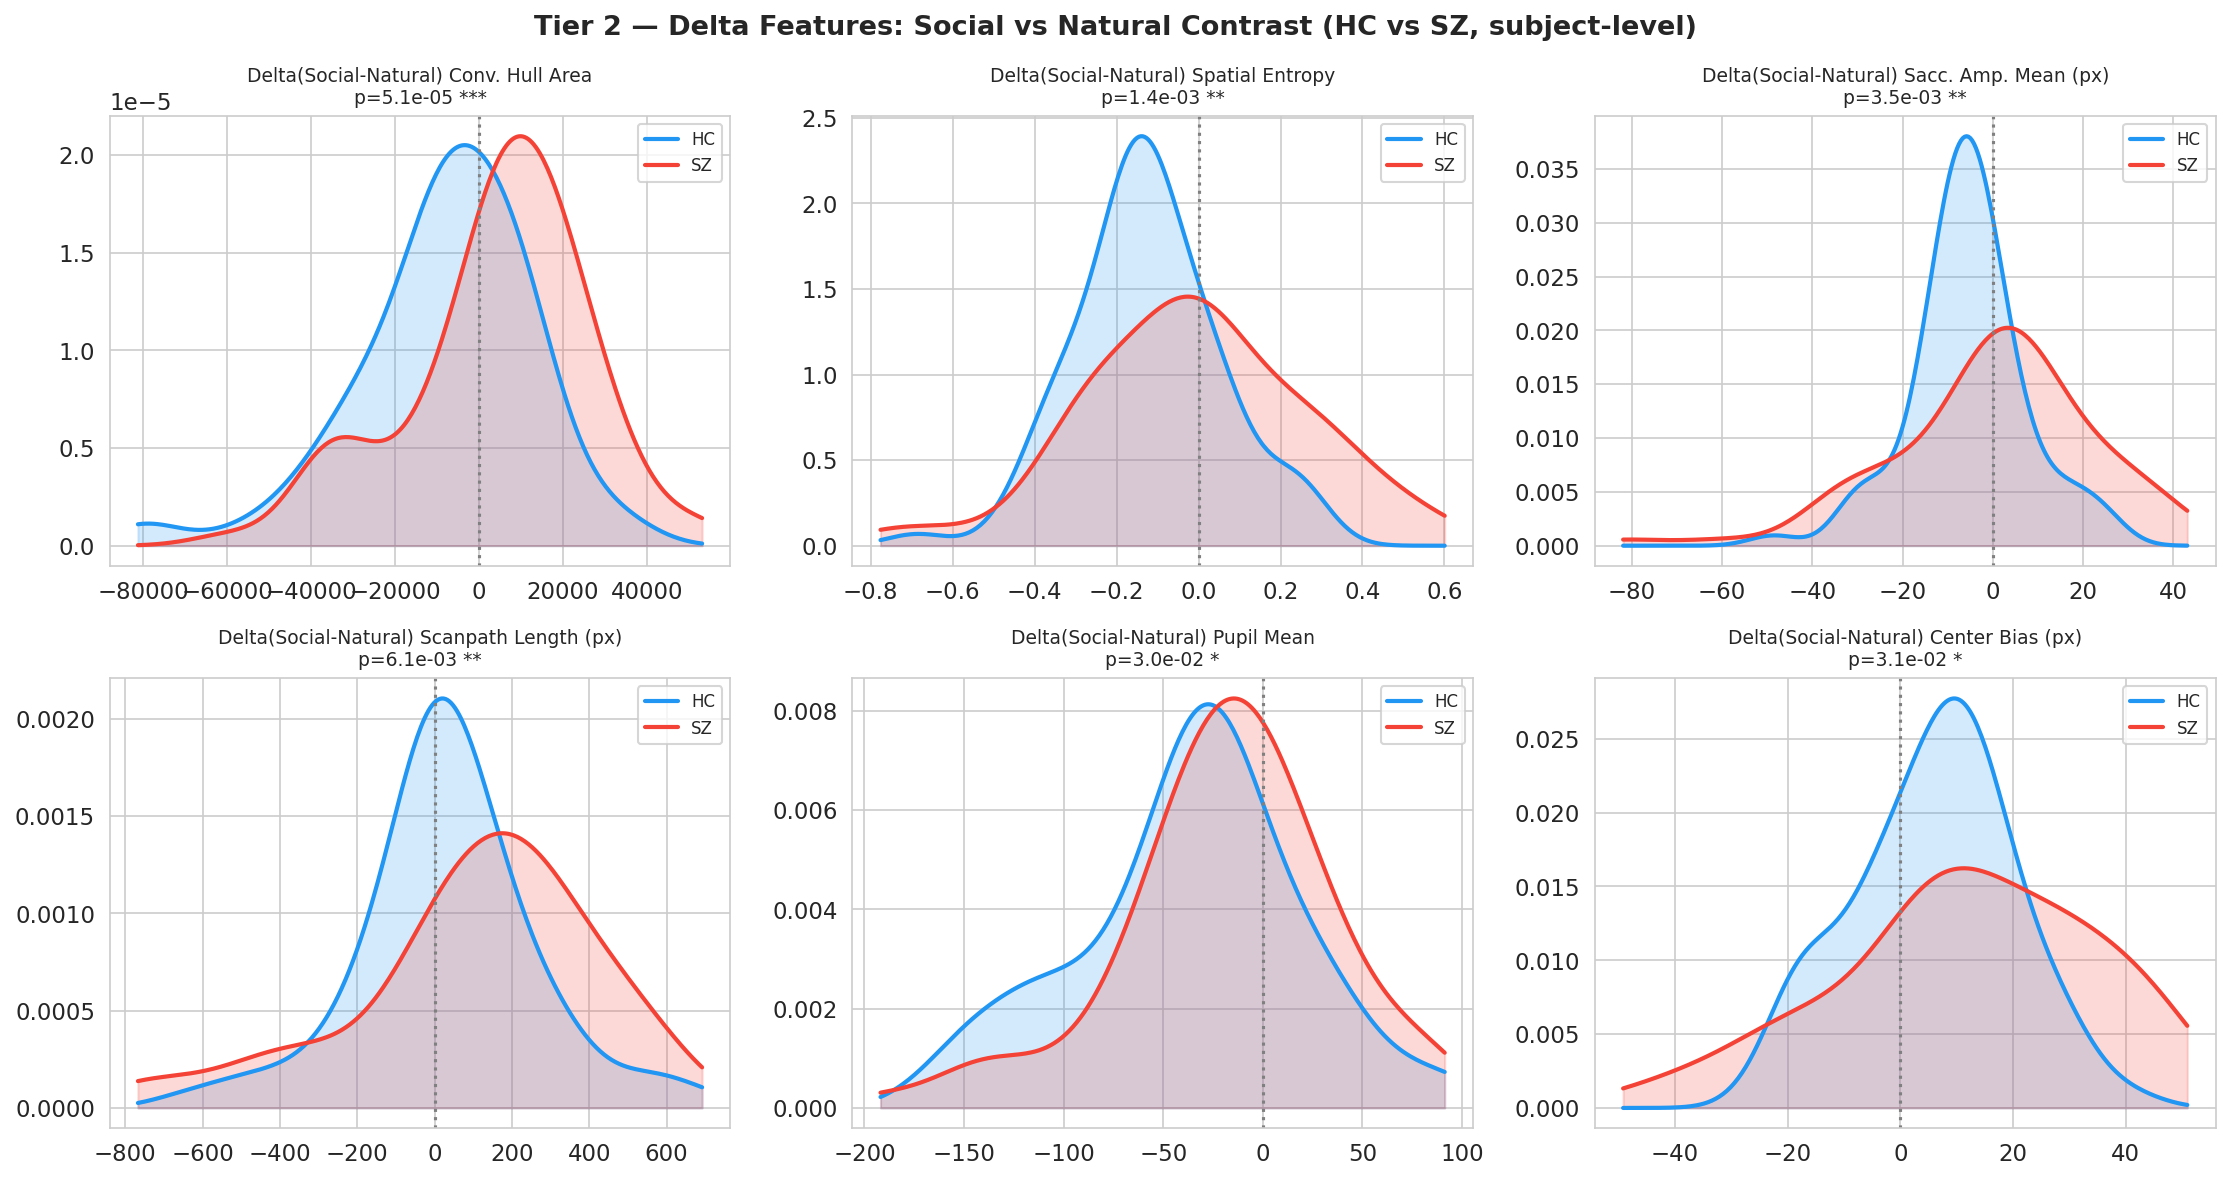

Saved: tier2_delta_density.png


In [ ]:
# ── Section 2: Feature Engineering Visualizations ───────────────────────────

# 2A: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 9))
corr = df_st[STIM_FEAT_COLS].corr()
labels = [FEAT_LABELS[c] for c in STIM_FEAT_COLS]
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8},
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax.set_title('Pearson Correlation — 15 Stimulus-Level Features (Tier 2)',
             fontweight='bold', pad=12, fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
fig.tight_layout()
fig.savefig(RES / 'tier2_correlation_heatmap.png', bbox_inches='tight')
plt.show(); print('Saved: tier2_correlation_heatmap.png')

# 2B: Top-8 most discriminative features (violin plots)
pvals_stim = {}
for col in STIM_FEAT_COLS:
    hc_v = df_st[df_st['Label']==0][col].dropna()
    sz_v = df_st[df_st['Label']==1][col].dropna()
    if len(hc_v) > 1 and len(sz_v) > 1:
        _, p = stats.mannwhitneyu(hc_v, sz_v, alternative='two-sided')
        pvals_stim[col] = p
top8 = sorted(pvals_stim, key=pvals_stim.get)[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Tier 2 — Top 8 Discriminative Features: HC vs SZ\n'
             '(Mann-Whitney U test, stimulus-level trials)', fontweight='bold', fontsize=13)
for ax, feat in zip(axes.flat, top8):
    hc_v = df_st[df_st['Label']==0][feat].dropna().values
    sz_v = df_st[df_st['Label']==1][feat].dropna().values
    vp = ax.violinplot([hc_v, sz_v], positions=[0,1], showmedians=True, showextrema=False)
    vp['bodies'][0].set_facecolor(C_HC); vp['bodies'][1].set_facecolor(C_SZ)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)
    p = pvals_stim[feat]
    stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ax.set_xticks([0,1]); ax.set_xticklabels(['HC','SZ'], fontsize=10)
    ax.set_title(f'{FEAT_LABELS.get(feat,feat)}\np={p:.1e} {stars}', fontsize=9)
fig.tight_layout()
fig.savefig(RES / 'tier2_feature_violin.png', bbox_inches='tight')
plt.show(); print('Saved: tier2_feature_violin.png')

# 2C: Delta features — Social vs Natural contrast
delta_info = []
for feat in STIM_FEAT_COLS:
    sc, nc = f'Social_{feat}', f'Natural_{feat}'
    if sc in df_sj.columns and nc in df_sj.columns:
        dc = f'delta_SocNat_{feat}'
        df_sj[dc] = df_sj[sc] - df_sj[nc]
        delta_info.append((feat, dc))

if delta_info:
    dpvals = {}
    for feat, dc in delta_info:
        hc_v = df_sj[df_sj['Label']==0][dc].dropna()
        sz_v = df_sj[df_sj['Label']==1][dc].dropna()
        if len(hc_v)>1 and len(sz_v)>1:
            _, p = stats.mannwhitneyu(hc_v, sz_v, alternative='two-sided')
            dpvals[dc] = p
    top6_delta = sorted(dpvals, key=dpvals.get)[:6]
    feat_name_map = {dc: feat for feat, dc in delta_info}

    from scipy.stats import gaussian_kde
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Tier 2 — Delta Features: Social vs Natural Contrast (HC vs SZ, subject-level)',
                 fontweight='bold', fontsize=13)
    for ax, dc in zip(axes.flat, top6_delta):
        hc_v = df_sj[df_sj['Label']==0][dc].dropna().values
        sz_v = df_sj[df_sj['Label']==1][dc].dropna().values
        base = FEAT_LABELS.get(feat_name_map.get(dc,''), dc)
        xr = np.linspace(min(hc_v.min(), sz_v.min()), max(hc_v.max(), sz_v.max()), 300)
        try:
            ax.plot(xr, gaussian_kde(hc_v)(xr), color=C_HC, lw=2, label='HC')
            ax.fill_between(xr, gaussian_kde(hc_v)(xr), alpha=0.2, color=C_HC)
            ax.plot(xr, gaussian_kde(sz_v)(xr), color=C_SZ, lw=2, label='SZ')
            ax.fill_between(xr, gaussian_kde(sz_v)(xr), alpha=0.2, color=C_SZ)
        except Exception:
            ax.hist(hc_v, bins=20, alpha=0.5, color=C_HC, density=True, label='HC')
            ax.hist(sz_v, bins=20, alpha=0.5, color=C_SZ, density=True, label='SZ')
        p = dpvals.get(dc, 1)
        stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        ax.axvline(0, color='gray', ls=':', lw=1.5)
        ax.set_title(f'Delta(Social-Natural) {base}\np={p:.1e} {stars}', fontsize=9)
        ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(RES / 'tier2_delta_density.png', bbox_inches='tight')
    plt.show(); print('Saved: tier2_delta_density.png')
else:
    print('No Social/Natural columns found in subject-level CSV.')
    print('Columns sample:', df_sj.columns[:20].tolist())

---
## Section 3 — Tabular Baselines & SHAP (Tier 3)

CatBoost (AUC≈0.899) outperforms XGBoost (0.872).  
SHAP analysis shows **delta features** (Social–Natural contrasts in fixation count and center bias) are the top predictors — consistent with social gaze avoidance as a key diagnostic signal in SZ.

In [ ]:
!pip install shap catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.2 MB/s eta 0:00:00


Training CatBoost on 135 features, 160 subjects...
CatBoost train AUC: 1.0000


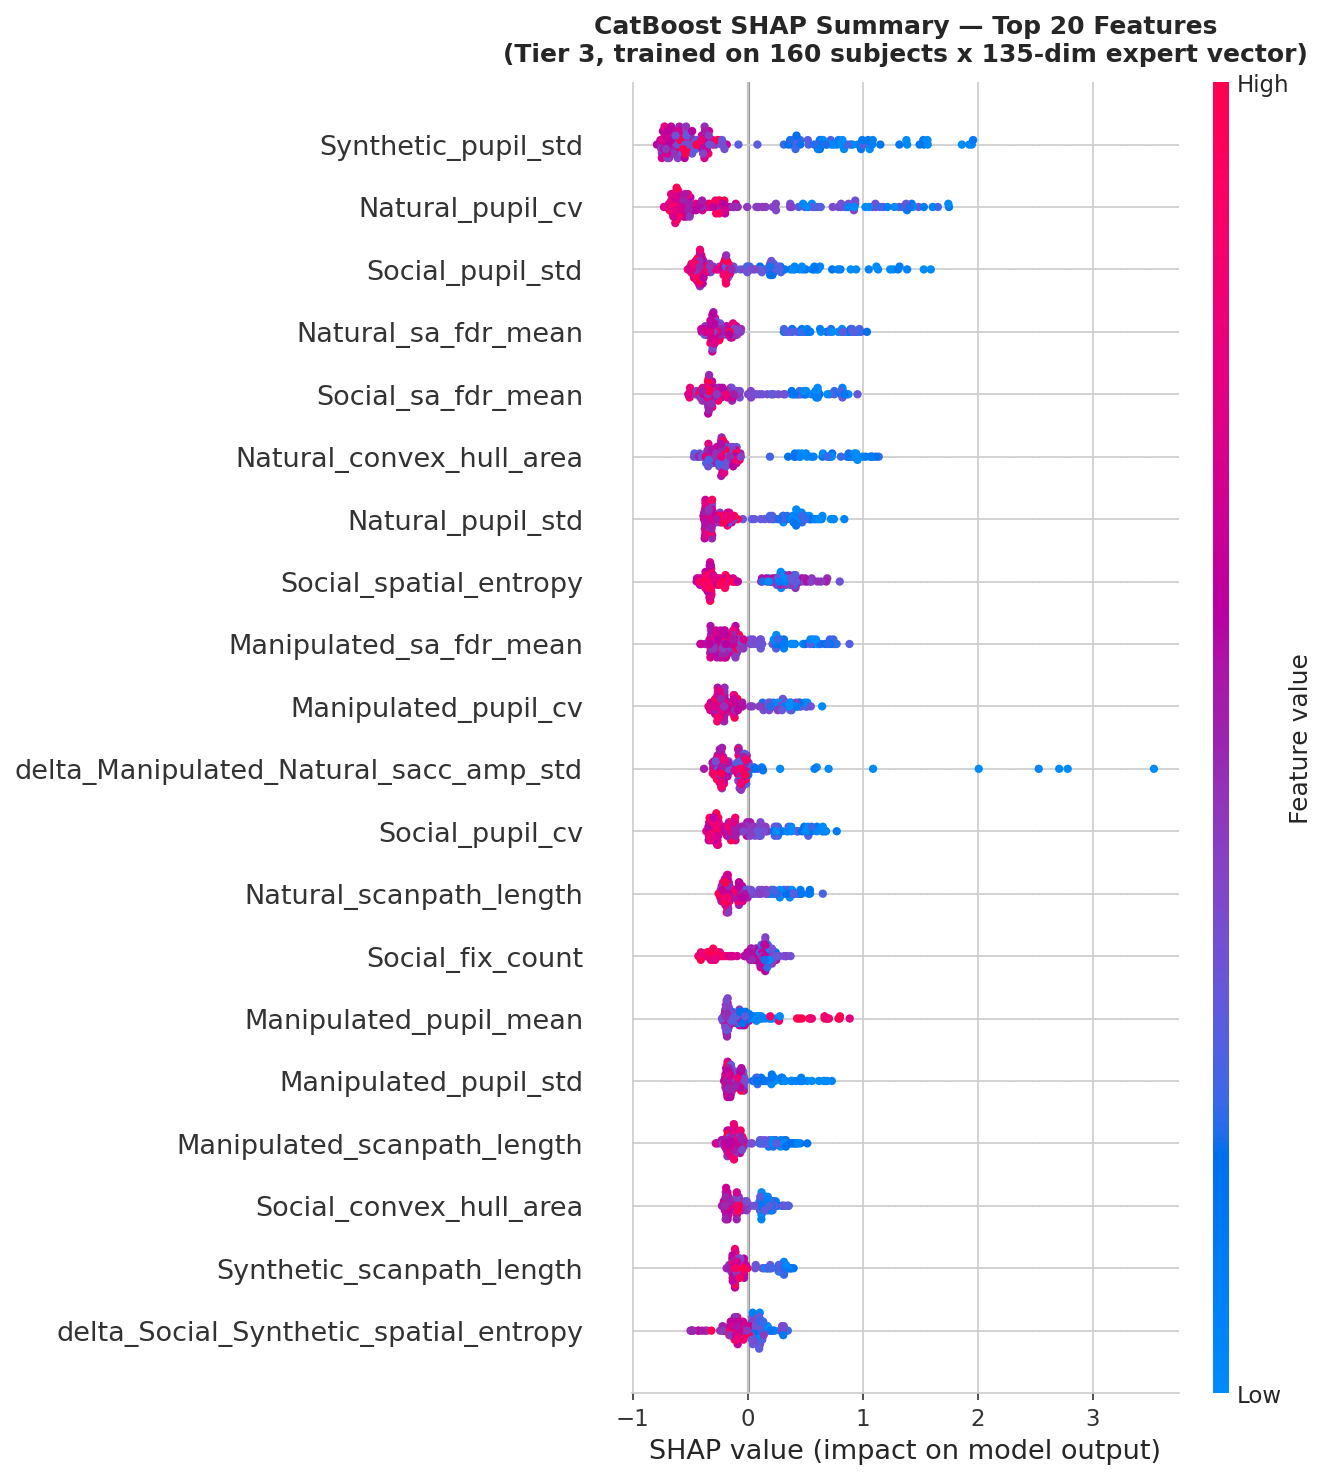

Saved: tier3_shap_summary.png


In [ ]:
# ── Section 3: SHAP Analysis (CatBoost retrained on 160 subjects) ────────────
try:
    from catboost import CatBoostClassifier
    import shap
    SHAP_OK = True
except ImportError as e:
    print(f'Skipping SHAP: {e}')
    print('Install: !pip install catboost shap')
    SHAP_OK = False

if SHAP_OK:
    base_feat_cols = [c for c in df_sj.columns
                      if c not in ['Subject_ID','Label','Is_Test','Group']
                      and not c.startswith('delta_')]
    delta_cols = [c for c in df_sj.columns if c.startswith('delta_')]
    all_feat_cols = base_feat_cols + delta_cols
    print(f'Training CatBoost on {len(all_feat_cols)} features, {len(df_sj)} subjects...')

    X_shap = df_sj[all_feat_cols].values
    y_shap = df_sj['Label'].values

    model_cb = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=42, verbose=0
    )
    model_cb.fit(X_shap, y_shap)
    print(f'CatBoost train AUC: {roc_auc_score(y_shap, model_cb.predict_proba(X_shap)[:,1]):.4f}')

    explainer_glob = shap.TreeExplainer(model_cb)
    sv_glob = explainer_glob.shap_values(X_shap)
    if isinstance(sv_glob, list):
        sv_glob = sv_glob[1]

    mean_abs = np.abs(sv_glob).mean(axis=0)
    top20 = np.argsort(mean_abs)[::-1][:20]
    top20_names = [all_feat_cols[i] for i in top20]

    fig, ax = plt.subplots(figsize=(9, 10))
    shap.summary_plot(sv_glob[:, top20], X_shap[:, top20], feature_names=top20_names,
                      show=False, plot_size=None)
    plt.title('CatBoost SHAP Summary — Top 20 Features\n'
              '(Tier 3, trained on 160 subjects x 135-dim expert vector)',
              fontweight='bold', pad=10, fontsize=12)
    plt.tight_layout()
    plt.savefig(RES / 'tier3_shap_summary.png', bbox_inches='tight')
    plt.show(); print('Saved: tier3_shap_summary.png')
else:
    print('SHAP analysis skipped — install catboost and shap first.')

---
## Section 4 — Deep Sequential Model Analysis (Tier 4)

| Model | Architecture | AUC (seed 42) | Sensitivity@τ=0.50 | Notes |
|---|---|---|---|---|
| ST-GNN | 2-layer GCN | 0.9378 | 62.5% | Calibration issue: τ=0.40 needed |
| GNN-CEFAM | GAT + CEFAM bidirectional cross-attention | 0.9119 | — | Training instability (4/12 fold-seed runs ≤ epoch 1) |
| **BiCA-HS** | 4-layer Transformer + 135-dim expert + BiCA | **0.9581** | **88.75%** | Best single model |

In [ ]:
# ── Load All OOF Predictions (Seed 42) ───────────────────────────────────────
CATS = ['Social', 'Natural', 'Manipulated', 'Synthetic']

def load_oof(path, prob_col='Pred_Proba_Subject'):
    df = pd.read_csv(path)
    keep = ['Subject_ID','Label'] + [c for c in CATS if c in df.columns] + [prob_col]
    keep = [c for c in keep if c in df.columns]
    return df[keep].rename(columns={prob_col: 'prob'})

OOF_PATHS = {
    'XGBoost':    RES / 'baselines_s42' / 'xgboost_oof_subject_preds.csv',
    'CatBoost':   RES / 'baselines_s42' / 'catboost_oof_subject_preds.csv',
    'ST-GNN':     RES / 'stgnn_s42'     / 'stgnn_oof_subject_preds.csv',
    'GNN-CEFAM':  RES / 'cefam_s42'     / 'cefam_oof_subject_preds.csv',
    'BiCA-HS':    RES / 'bica_s42'       / 'bica_subject_val_predictions.csv',
    'Tier5+BiCA': RES / 'tier5_bica_s42' / 'tier5_oof_subject_preds.csv',
}

oof = {}
for name, path in OOF_PATHS.items():
    if path.exists():
        oof[name] = load_oof(path)
        print(f'{name:15s}: {len(oof[name])} subjects | cols: {oof[name].columns.tolist()}')
    else:
        print(f'{name:15s}: NOT FOUND — {path}')

# Merge all predictions into one aligned DataFrame
base_oof = oof.get('BiCA-HS', next(iter(oof.values())))[['Subject_ID','Label']].copy()
df_all = base_oof.copy()
for name, df in oof.items():
    df_all = df_all.merge(df[['Subject_ID','prob']].rename(columns={'prob': name}),
                          on='Subject_ID', how='left')
y_true = df_all['Label'].values
print(f'\nAligned OOF: {df_all.shape}')

XGBoost        : 160 subjects | cols: ['Subject_ID', 'Label', 'Social', 'Natural', 'Manipulated', 'Synthetic', 'prob']
CatBoost       : 160 subjects | cols: ['Subject_ID', 'Label', 'Social', 'Natural', 'Manipulated', 'Synthetic', 'prob']
ST-GNN         : 160 subjects | cols: ['Subject_ID', 'Label', 'Social', 'Natural', 'Manipulated', 'Synthetic', 'prob']
GNN-CEFAM      : 160 subjects | cols: ['Subject_ID', 'Label', 'Social', 'Natural', 'Manipulated', 'Synthetic', 'prob']
BiCA-HS        : 160 subjects | cols: ['Subject_ID', 'Label', 'Social', 'Natural', 'Manipulated', 'Synthetic', 'prob']
Tier5+BiCA     : 160 subjects | cols: ['Subject_ID', 'Label', 'prob']

Aligned OOF: (160, 8)


Per-category AUC (seed 42):
           Social  Natural  Manipulated  Synthetic
CatBoost   0.8981   0.8981       0.8981     0.8981
ST-GNN     0.9159   0.9395       0.9333     0.9459
GNN-CEFAM  0.9117   0.9086       0.9158     0.9080
BiCA-HS    0.9577   0.9559       0.9561     0.9575


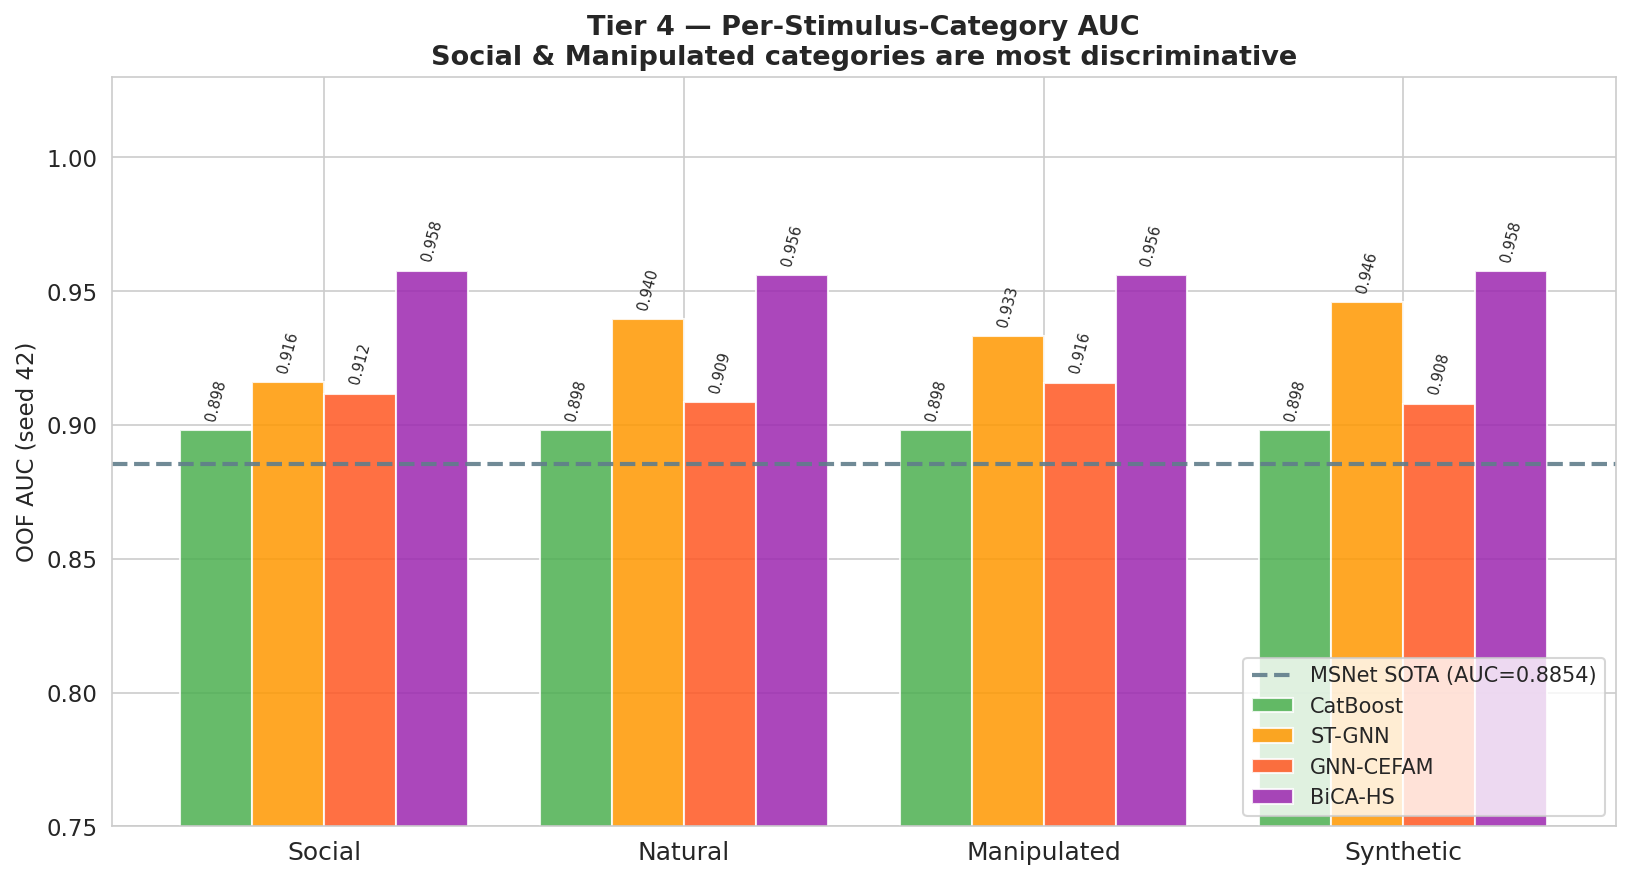

Saved: F3_category_analysis.png


In [ ]:
# ── Per-Category AUC Analysis (Figure F3) ───────────────────────────────────
cat_auc = {}
for name in ['CatBoost','ST-GNN','GNN-CEFAM','BiCA-HS']:
    if name not in oof: continue
    df_m = oof[name]
    row  = {}
    for cat in CATS:
        if cat in df_m.columns:
            merged = base_oof.merge(df_m[['Subject_ID', cat]], on='Subject_ID', how='left')
            try:
                row[cat] = roc_auc_score(merged['Label'], merged[cat])
            except Exception:
                row[cat] = np.nan
        else:
            row[cat] = roc_auc_score(y_true, df_all[name]) if name in df_all else np.nan
    cat_auc[name] = row

df_cat = pd.DataFrame(cat_auc).T
print('Per-category AUC (seed 42):')
print(df_cat.round(4))

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(CATS))
w = 0.20
mods = list(df_cat.index)
mcolors = {'CatBoost':C_CAT,'ST-GNN':C_STGNN,'GNN-CEFAM':C_CEFAM,'BiCA-HS':C_BICA}
for i, nm in enumerate(mods):
    vals = [df_cat.loc[nm, c] for c in CATS]
    ax.bar(x + i*w, vals, w, label=nm, color=mcolors.get(nm,'gray'),
           alpha=0.85, edgecolor='white')
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j]+i*w, v+0.003, f'{v:.3f}', ha='center', va='bottom',
                    fontsize=7, rotation=75)
ax.axhline(SOTA_AUC, color=C_SOTA, ls='--', lw=2, alpha=0.9,
           label=f'MSNet SOTA (AUC={SOTA_AUC})')
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(CATS, fontsize=12)
ax.set_ylabel('OOF AUC (seed 42)', fontsize=11)
ax.set_title('Tier 4 — Per-Stimulus-Category AUC\n'
             'Social & Manipulated categories are most discriminative',
             fontweight='bold', fontsize=13)
ax.set_ylim(0.75, 1.03)
ax.legend(fontsize=10, loc='lower right')
fig.tight_layout()
fig.savefig(ABL / 'F3_category_analysis.png', bbox_inches='tight')
plt.show(); print('Saved: F3_category_analysis.png')

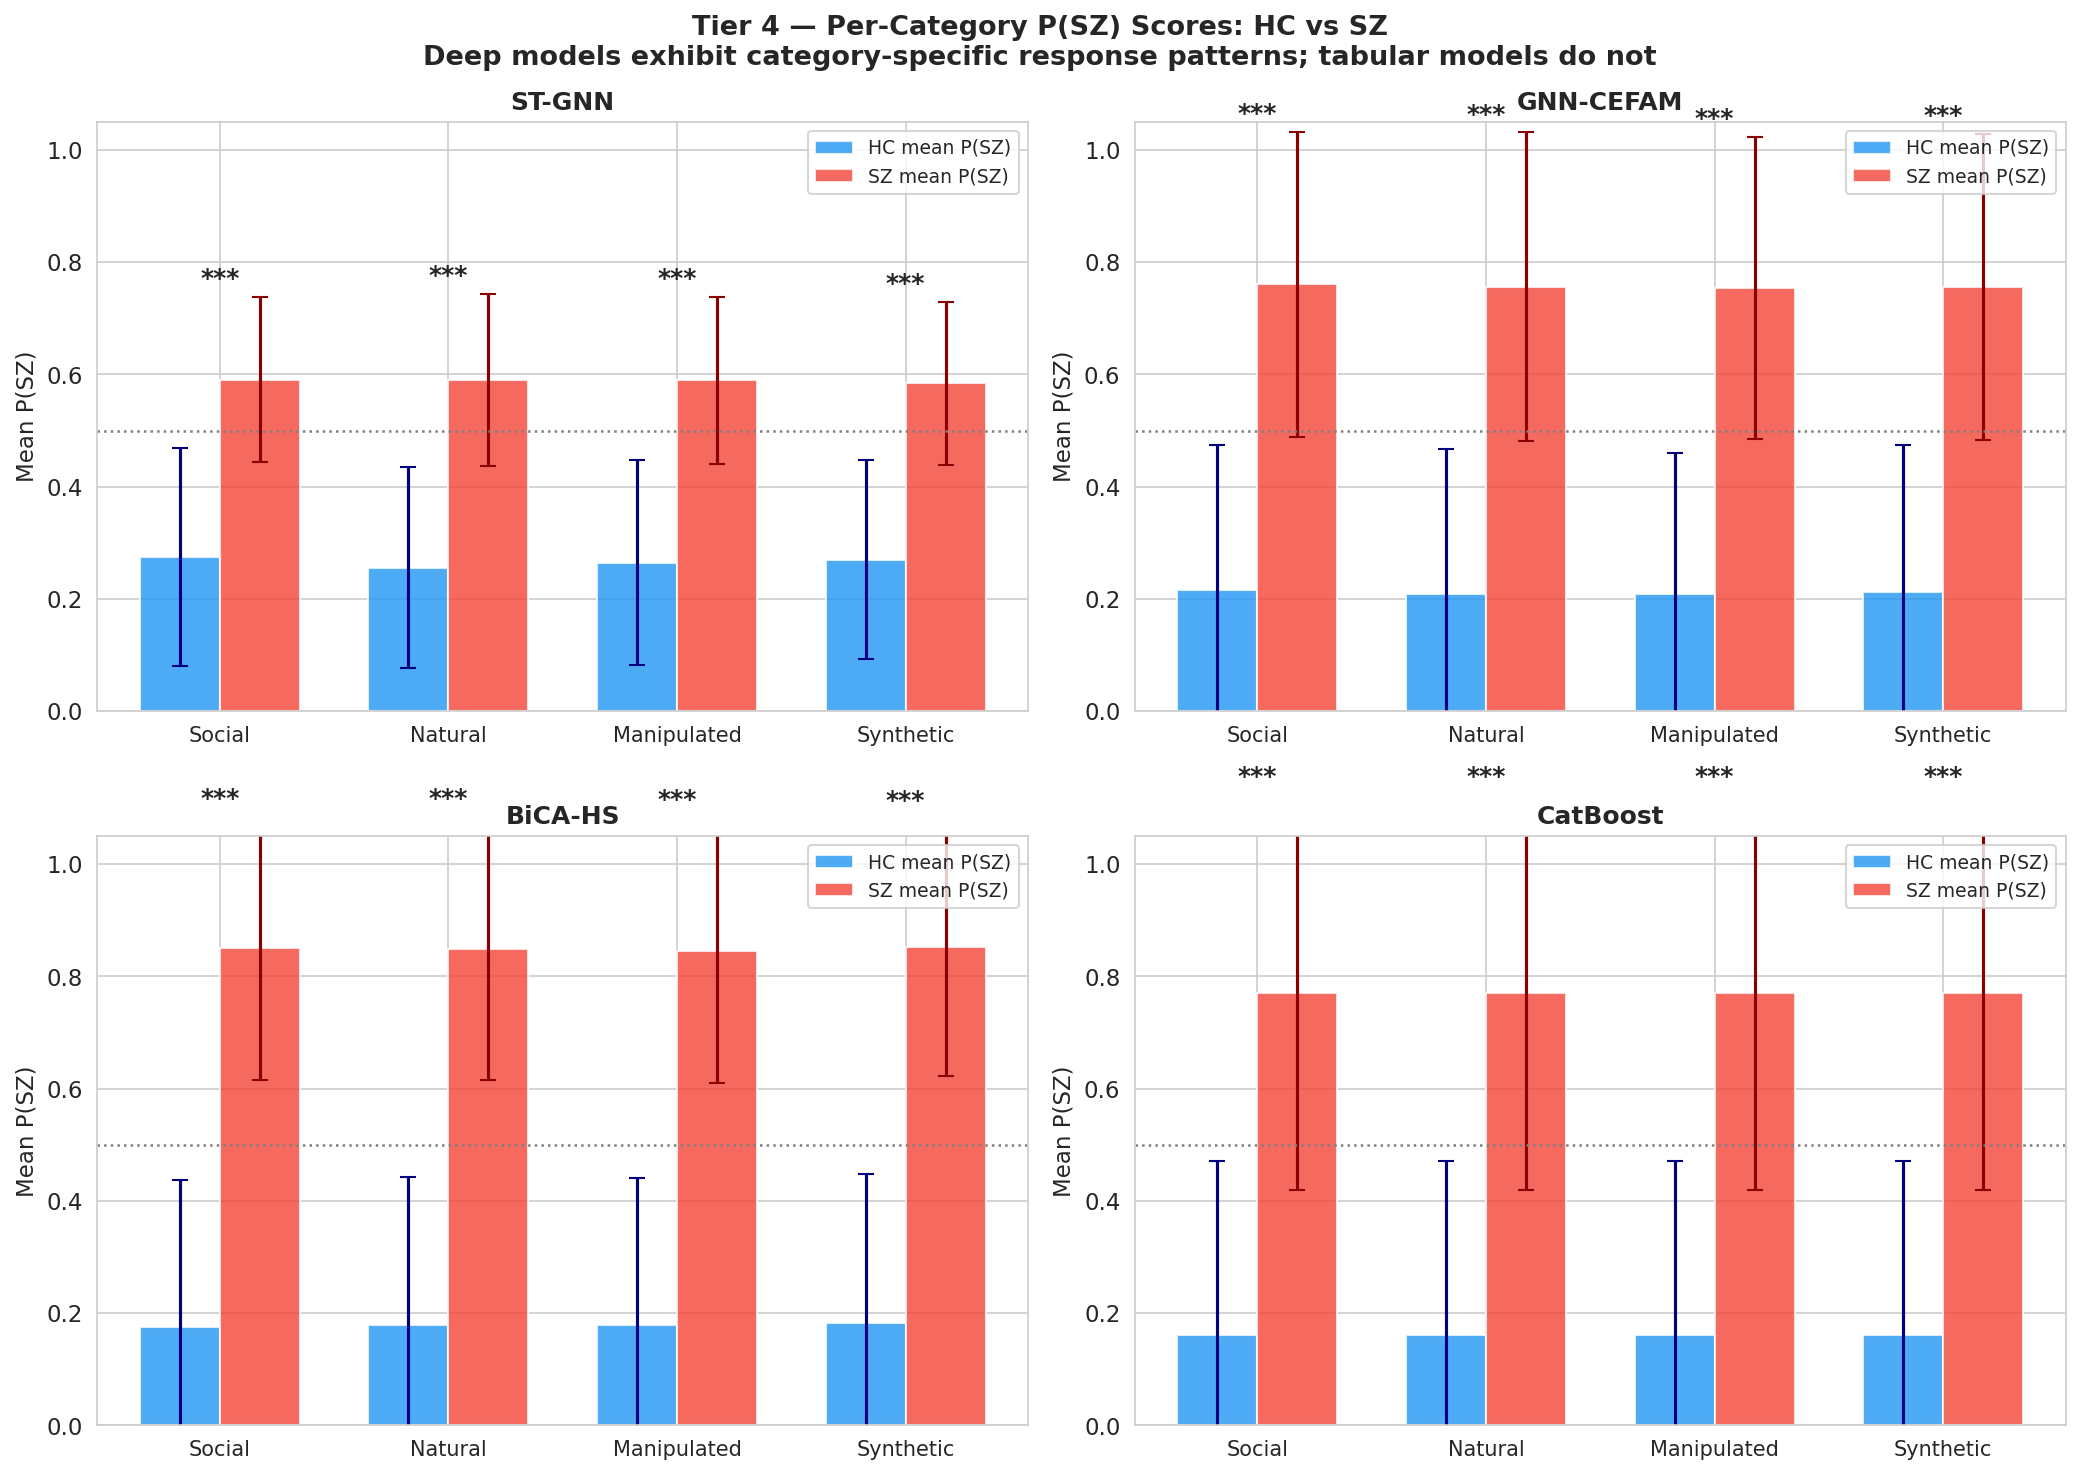

Saved: tier4_scanpath_attention.png


In [ ]:
# ── Category Response Patterns: Mean P(SZ) by Group ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Tier 4 — Per-Category P(SZ) Scores: HC vs SZ\n'
    'Deep models exhibit category-specific response patterns; tabular models do not',
    fontweight='bold', fontsize=13
)
model_items = [('ST-GNN', C_STGNN), ('GNN-CEFAM', C_CEFAM),
               ('BiCA-HS', C_BICA),  ('CatBoost',  C_CAT)]
for ax, (nm, mc) in zip(axes.flat, model_items):
    if nm not in oof:
        ax.set_visible(False); continue
    df_m = oof[nm].merge(base_oof[['Subject_ID','Label']], on='Subject_ID', how='right')
    avail = [c for c in CATS if c in df_m.columns]
    if not avail:
        ax.set_visible(False); continue
    hc_m = [df_m[df_m['Label_x']==0][c].mean() for c in avail]
    sz_m = [df_m[df_m['Label_x']==1][c].mean() for c in avail]
    hc_std = [df_m[df_m['Label_x']==0][c].std() for c in avail]
    sz_std = [df_m[df_m['Label_x']==1][c].std() for c in avail]
    xb = np.arange(len(avail)); wb = 0.35
    ax.bar(xb-wb/2, hc_m, wb, color=C_HC, alpha=0.8, label='HC mean P(SZ)', edgecolor='white')
    ax.bar(xb+wb/2, sz_m, wb, color=C_SZ, alpha=0.8, label='SZ mean P(SZ)', edgecolor='white')
    ax.errorbar(xb-wb/2, hc_m, yerr=hc_std, fmt='none', color='navy', capsize=4, elinewidth=1.5)
    ax.errorbar(xb+wb/2, sz_m, yerr=sz_std, fmt='none', color='darkred', capsize=4, elinewidth=1.5)
    for i, cat in enumerate(avail):
        hcv = df_m[df_m['Label_x']==0][cat].dropna()
        szv = df_m[df_m['Label_x']==1][cat].dropna()
        if len(hcv)>1 and len(szv)>1:
            _, p = stats.mannwhitneyu(hcv, szv)
            stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
            if stars:
                ypos = max(hc_m[i]+hc_std[i], sz_m[i]+sz_std[i]) + 0.02
                ax.text(i, ypos, stars, ha='center', fontsize=12, fontweight='bold')
    ax.set_xticks(xb); ax.set_xticklabels(avail, fontsize=10)
    ax.set_ylabel('Mean P(SZ)'); ax.set_ylim(0, 1.05)
    ax.set_title(nm, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.axhline(0.5, color='gray', ls=':', lw=1.2)
fig.tight_layout()
fig.savefig(RES / 'tier4_scanpath_attention.png', bbox_inches='tight')
plt.show(); print('Saved: tier4_scanpath_attention.png')

---
## Section 5 — Ensemble & SOTA Comparison (Tier 5)

BiCA-HS: AUC=**0.9549±0.0039** | Tier5+BiCA: AUC=**0.9590±0.0009** (both *p*<0.001 vs MSNet, bootstrap n=5,000).  

**Clinical insight**: ST-GNN AUC=0.933 but Sensitivity=62.5% at τ=0.50 (threshold recalibration required). BiCA-HS maintains Sensitivity=87.5% at τ=0.50 — clinically superior without threshold tuning.

In [ ]:
# ── Multi-Seed Result Aggregation (seeds 42, 123, 456) ──────────────────────
RESULT_SPEC = {
    'XGBoost':     ('baselines',  'xgboost_results_summary.json',  'subject_level'),
    'CatBoost':    ('baselines',  'catboost_results_summary.json', 'subject_level'),
    'ST-GNN':      ('stgnn',      'stgnn_results_summary.json',    'overall'),
    'GNN-CEFAM':   ('cefam',      'cefam_results_summary.json',    'overall'),
    'BiCA-HS':     ('bica',       'bica_results_summary.json',     'overall'),
    'Tier5+BiCA':  ('tier5_bica', 'tier5_results_summary.json',    'tier5_metrics'),
}

seed_rows = []
for model, (pfx, fname, key) in RESULT_SPEC.items():
    for seed in SEEDS:
        fp = RES / f'{pfx}_{seed}' / fname
        if not fp.exists(): continue
        with open(fp) as f: d = json.load(f)
        m = d.get(key, {})
        if not m: continue
        seed_rows.append({
            'Model': model, 'Seed': seed,
            'AUC':  m.get('auc', np.nan),
            'ACC':  m.get('accuracy', np.nan),
            'F1':   m.get('f1', np.nan),
            'Sens': m.get('recall', np.nan),
            'Spec': m.get('specificity', np.nan),
        })

df_perf = pd.DataFrame(seed_rows)
agg = df_perf.groupby('Model').agg(
    AUC_mean=('AUC','mean'), AUC_std=('AUC','std'),
    ACC_mean=('ACC','mean'), ACC_std=('ACC','std'),
    F1_mean =('F1', 'mean'), F1_std =('F1', 'std'),
    Sens_mean=('Sens','mean'), Sens_std=('Sens','std'),
    Spec_mean=('Spec','mean'), Spec_std=('Spec','std'),
).reset_index()
agg_idx = agg.set_index('Model')

print('=== MULTI-SEED AGGREGATED RESULTS (mean \u00b1 std) ===')
print(f'{"Model":15s} {"AUC":20s} {"ACC":20s} {"Sens":20s} {"Spec":20s}')
print('-'*80)
for _, r in agg.iterrows():
    def fmt(mu, sd):
        if np.isnan(mu): return 'N/A'
        return f'{mu:.4f}\u00b1{sd:.4f}' if not np.isnan(sd) else f'{mu:.4f}'
    print(f"{r['Model']:15s} {fmt(r['AUC_mean'],r['AUC_std']):20s} "
          f"{fmt(r['ACC_mean'],r['ACC_std']):20s} "
          f"{fmt(r['Sens_mean'],r['Sens_std']):20s} "
          f"{fmt(r['Spec_mean'],r['Spec_std']):20s}")

=== MULTI-SEED AGGREGATED RESULTS (mean ± std) ===
Model           AUC                  ACC                  Sens                 Spec                
--------------------------------------------------------------------------------
BiCA-HS         0.9549±0.0048        0.8729±0.0157        0.8750±0.0573        0.8708±0.0260       
CatBoost        0.8990±0.0014        0.8104±0.0095        0.7833±0.0072        0.8375±0.0125       
GNN-CEFAM       0.9208±0.0078        0.8458±0.0130        0.8500±0.0125        0.8417±0.0260       
ST-GNN          0.9331±0.0105        0.7896±0.0036        0.6333±0.0072        0.9458±0.0072       
Tier5+BiCA      0.9590±0.0011        0.8854±0.0036        0.8875±0.0375        0.8833±0.0382       
XGBoost         0.8716±0.0057        0.7771±0.0130        0.7750±0.0250        0.7792±0.0191       


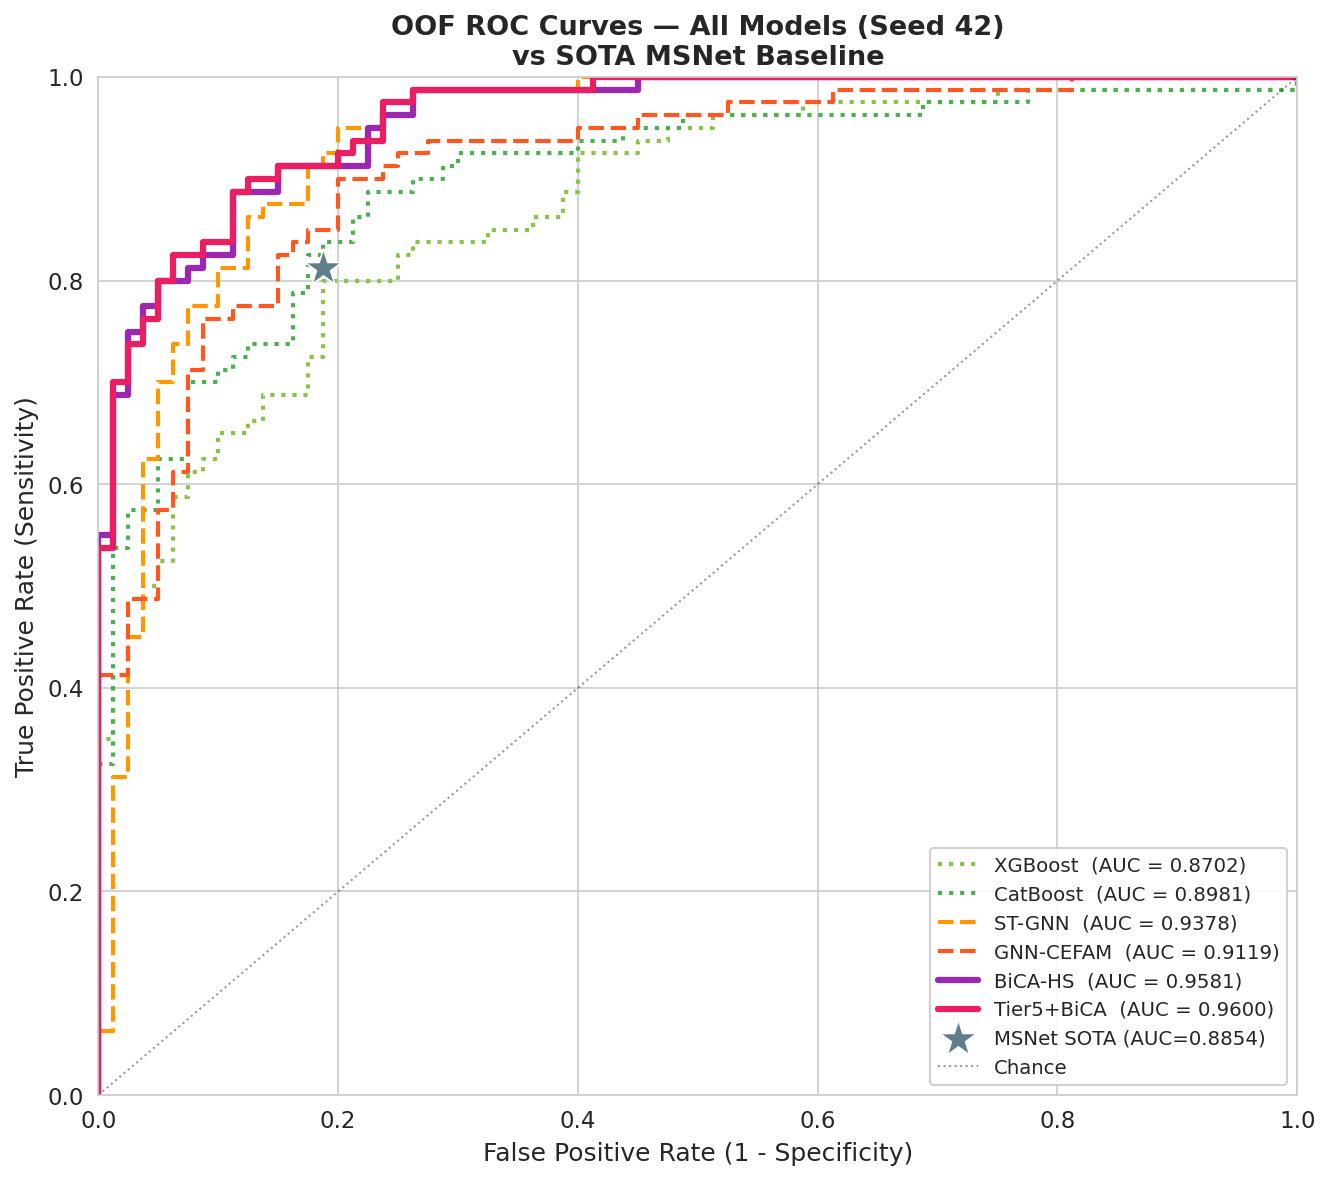

Saved: F7_roc_curves.png


In [ ]:
# ── ROC Curves — All Models (Figure F7) ─────────────────────────────────────
MODEL_COLORS = {
    'XGBoost':C_XGB, 'CatBoost':C_CAT,
    'ST-GNN':C_STGNN, 'GNN-CEFAM':C_CEFAM,
    'BiCA-HS':C_BICA, 'Tier5+BiCA':C_T5,
}
MODEL_LS = {
    'BiCA-HS':'-', 'Tier5+BiCA':'-', 'ST-GNN':'--',
    'GNN-CEFAM':'--', 'CatBoost':':', 'XGBoost':':'
}

fig, ax = plt.subplots(figsize=(9, 8))
for name, col in MODEL_COLORS.items():
    if name not in df_all.columns: continue
    preds = df_all[name].values
    mask  = ~np.isnan(preds)
    if mask.sum() < 10: continue
    fpr, tpr, _ = roc_curve(y_true[mask], preds[mask])
    auc_v = sk_auc(fpr, tpr)
    lw = 3 if name in ['BiCA-HS','Tier5+BiCA'] else 2
    ax.plot(fpr, tpr, color=col, lw=lw, ls=MODEL_LS.get(name,'-'),
            label=f'{name}  (AUC = {auc_v:.4f})')

ax.scatter([1-SOTA_ACC], [SOTA_ACC], marker='*', s=350, zorder=6,
           color=C_SOTA, label=f'MSNet SOTA (AUC={SOTA_AUC})',
           edgecolors='white', linewidths=0.8)
ax.plot([0,1],[0,1],'k:',lw=1,alpha=0.4, label='Chance')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('OOF ROC Curves — All Models (Seed 42)\nvs SOTA MSNet Baseline',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9.5, loc='lower right', framealpha=0.9)
ax.set_xlim(0,1); ax.set_ylim(0,1)
fig.tight_layout()
fig.savefig(ABL / 'F7_roc_curves.png', bbox_inches='tight')
plt.show(); print('Saved: F7_roc_curves.png')

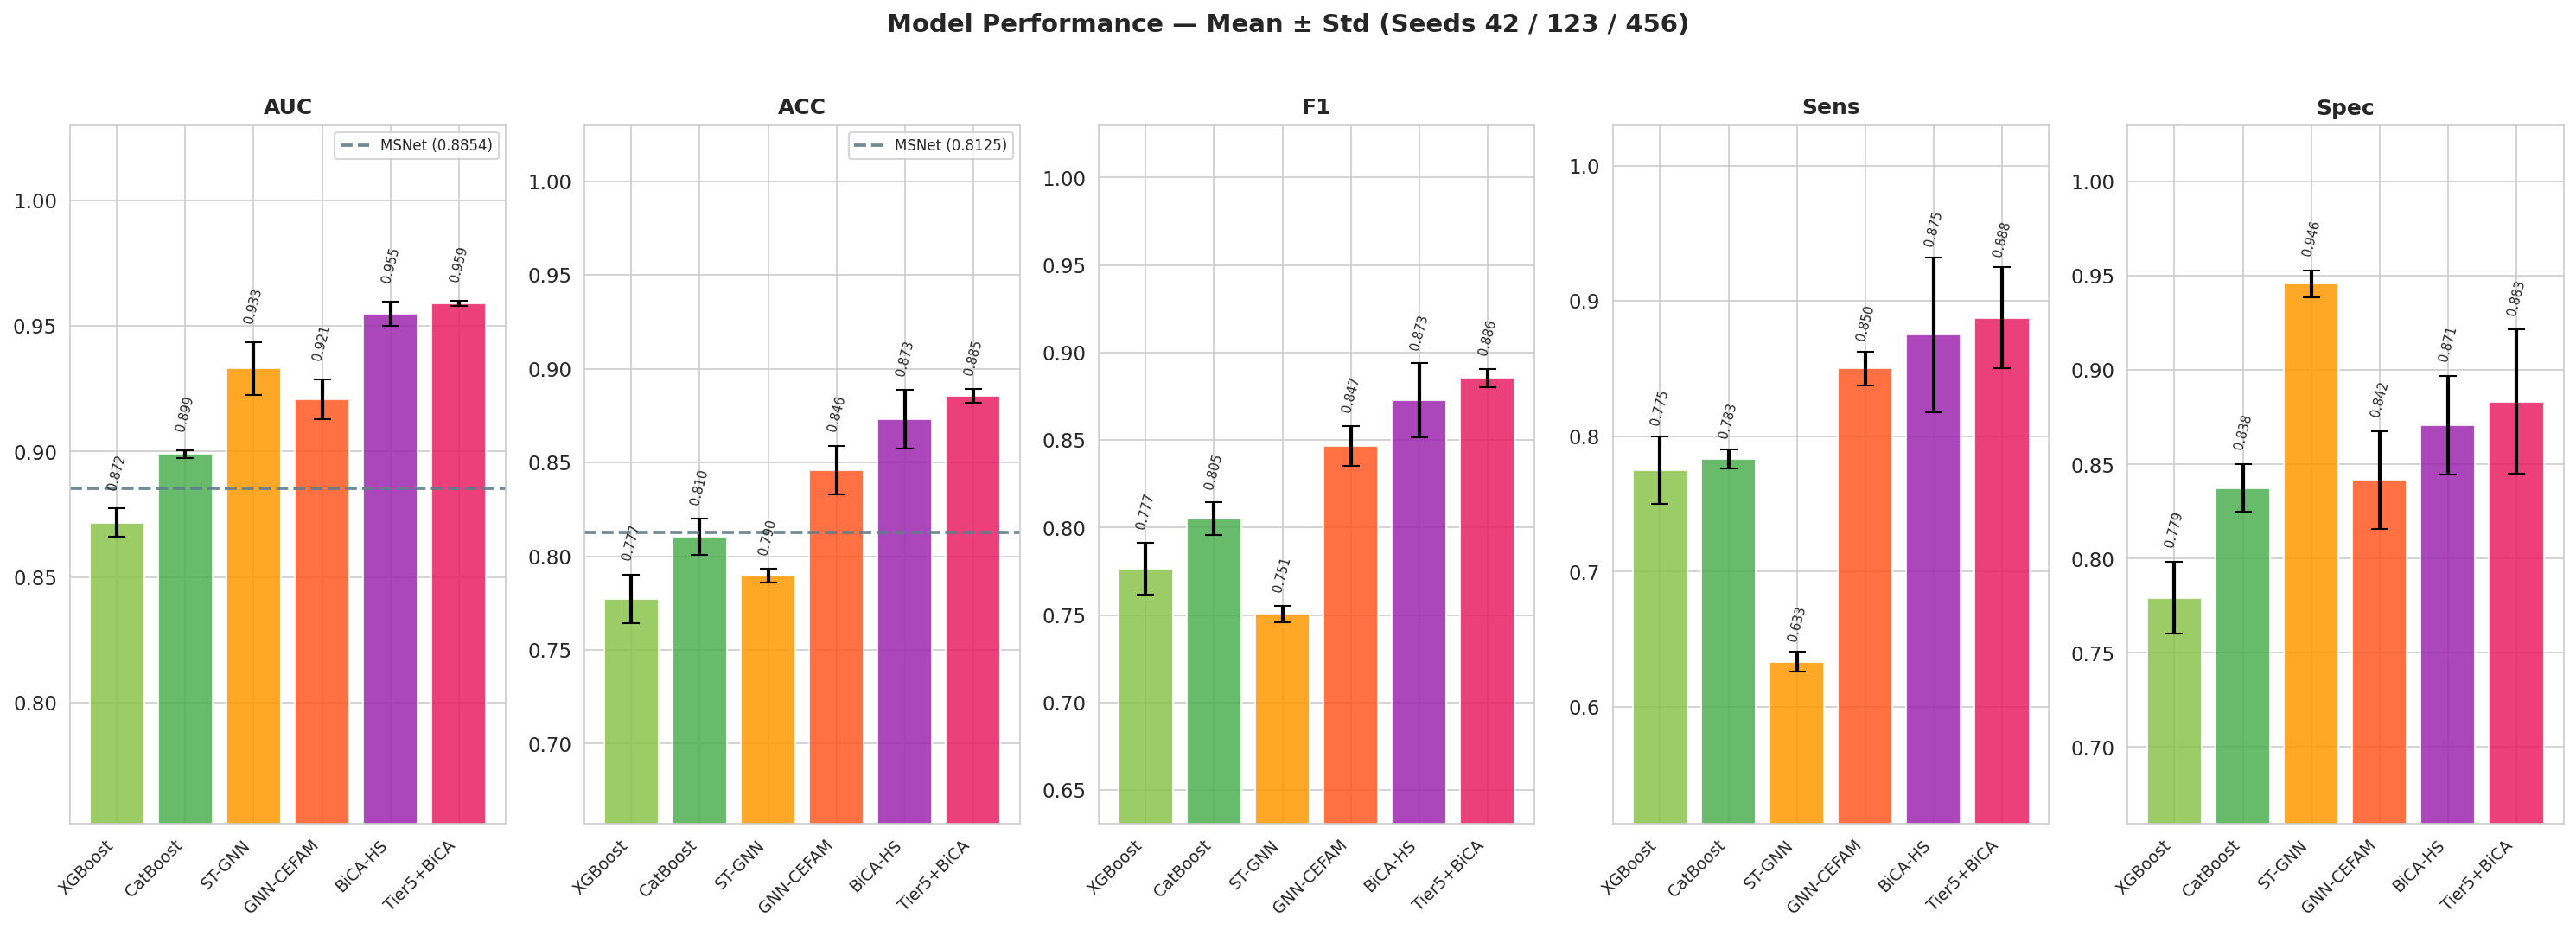

Saved: F1_model_comparison.png


In [ ]:
# ── Multi-Metric Model Comparison Bar Chart (Figure F1) ─────────────────────
MODEL_ORDER = ['XGBoost','CatBoost','ST-GNN','GNN-CEFAM','BiCA-HS','Tier5+BiCA']
COLS_PLOT   = [C_XGB, C_CAT, C_STGNN, C_CEFAM, C_BICA, C_T5]
METRICS_PLOT = [
    ('AUC',  'AUC_mean',  'AUC_std',  SOTA_AUC),
    ('ACC',  'ACC_mean',  'ACC_std',  SOTA_ACC),
    ('F1',   'F1_mean',   'F1_std',   None),
    ('Sens', 'Sens_mean', 'Sens_std', None),
    ('Spec', 'Spec_mean', 'Spec_std', None),
]

mods = [m for m in MODEL_ORDER if m in agg_idx.index]
clrs = [COLS_PLOT[MODEL_ORDER.index(m)] for m in mods]

fig, axes = plt.subplots(1, 5, figsize=(20, 7))
fig.suptitle('Model Performance — Mean \u00b1 Std (Seeds 42 / 123 / 456)',
             fontweight='bold', fontsize=14, y=1.02)

for ax, (metric, mcol, mstd, sota_v) in zip(axes, METRICS_PLOT):
    vals = [agg_idx.loc[m, mcol] if m in agg_idx.index else np.nan for m in mods]
    errs = [agg_idx.loc[m, mstd]
            if m in agg_idx.index and not np.isnan(agg_idx.loc[m, mstd])
            else 0 for m in mods]
    ax.bar(range(len(mods)), vals, color=clrs, alpha=0.85, edgecolor='white',
           yerr=errs, capsize=5, error_kw={'elinewidth':2})
    if sota_v is not None:
        ax.axhline(sota_v, color=C_SOTA, ls='--', lw=1.8, alpha=0.9,
                   label=f'MSNet ({sota_v:.4f})')
        ax.legend(fontsize=8)
    ax.set_xticks(range(len(mods)))
    ax.set_xticklabels(mods, rotation=45, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    valid_vals = [v for v in vals if not np.isnan(v)]
    if valid_vals:
        ax.set_ylim(max(0.5, min(valid_vals)-0.12), 1.03)
    for i, (v, e) in enumerate(zip(vals, errs)):
        if not np.isnan(v):
            ax.text(i, v+(e or 0)+0.007, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=7, rotation=75)
fig.tight_layout()
fig.savefig(ABL / 'F1_model_comparison.png', bbox_inches='tight')
plt.show(); print('Saved: F1_model_comparison.png')

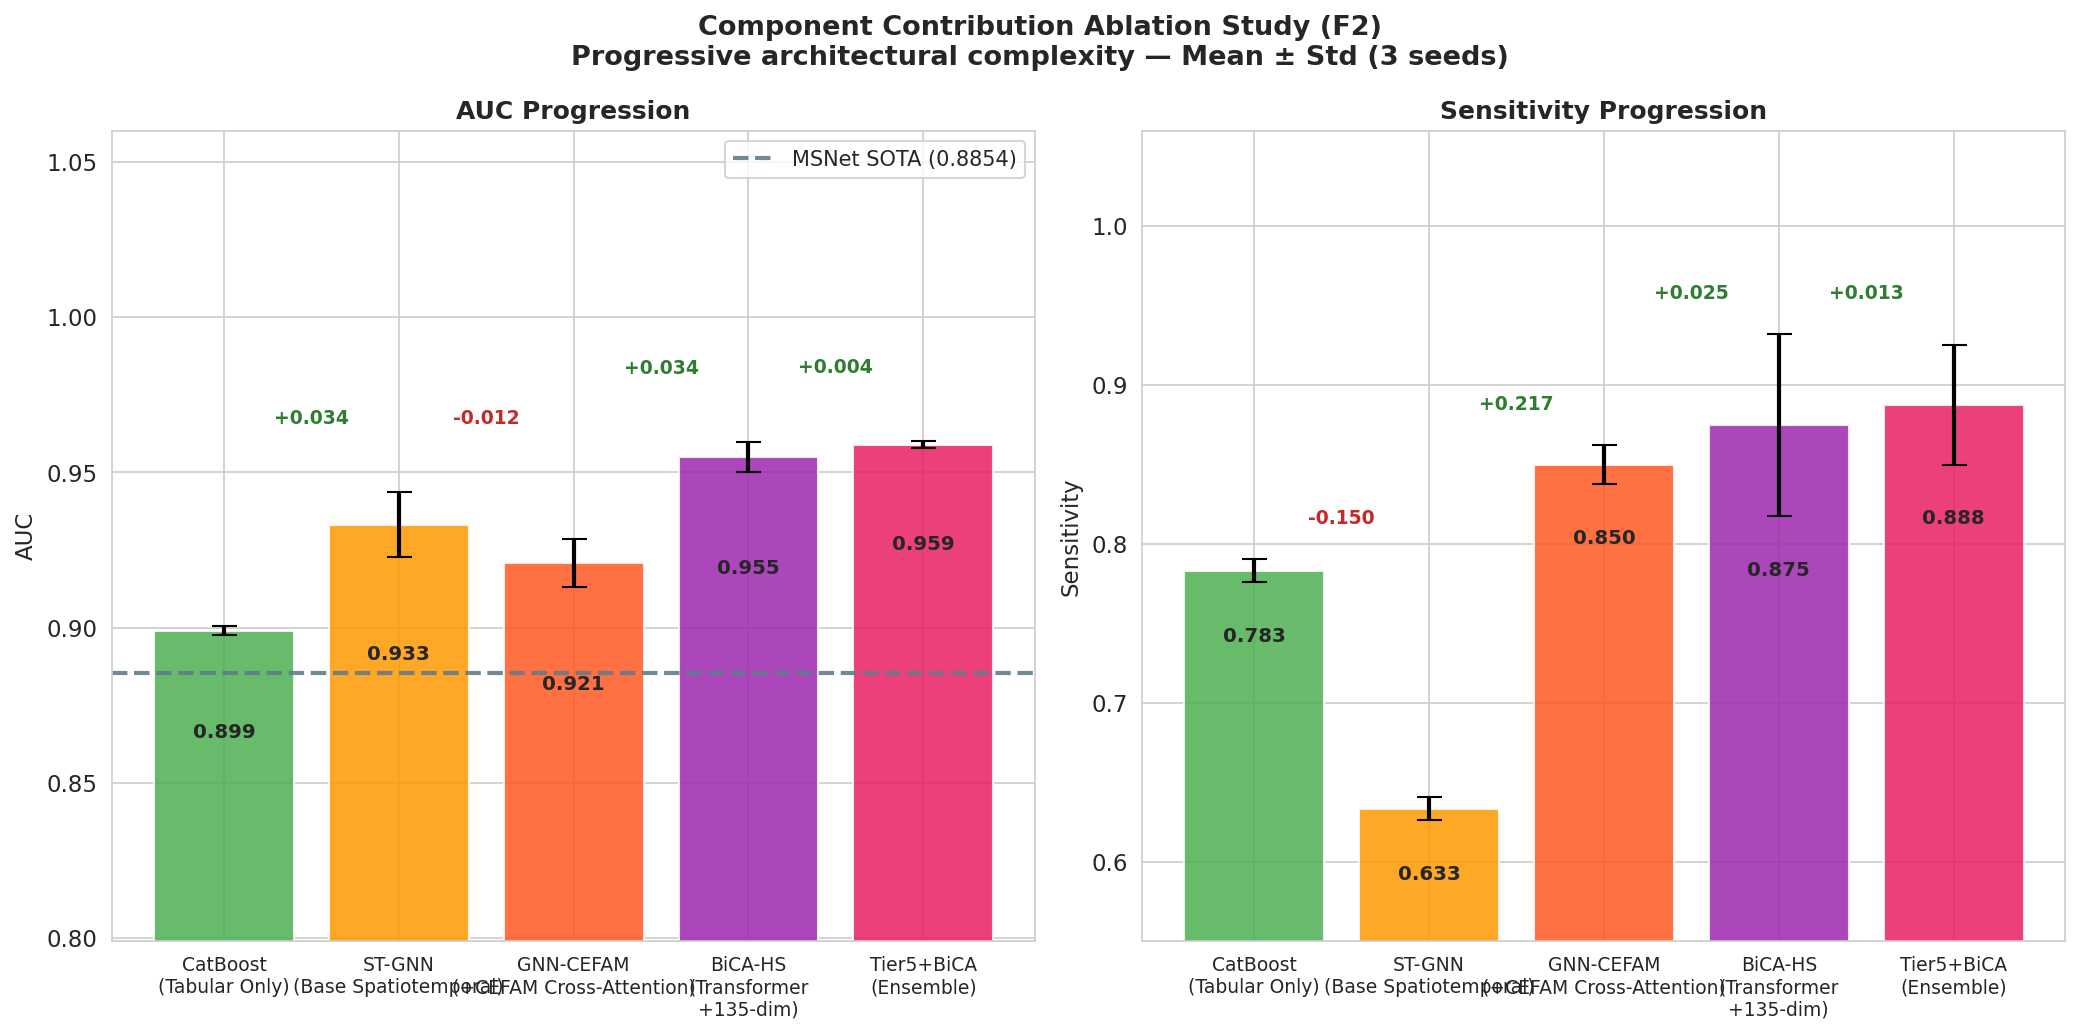

Saved: F2_component_contribution.png


In [ ]:
# ── Component Contribution Ablation (Figure F2) ─────────────────────────────
ABL_STEPS = [
    ('CatBoost\n(Tabular Only)',            'CatBoost',   C_CAT),
    ('ST-GNN\n(Base Spatiotemporal)',        'ST-GNN',     C_STGNN),
    ('GNN-CEFAM\n(+CEFAM Cross-Attention)', 'GNN-CEFAM',  C_CEFAM),
    ('BiCA-HS\n(Transformer\n+135-dim)',    'BiCA-HS',    C_BICA),
    ('Tier5+BiCA\n(Ensemble)',              'Tier5+BiCA', C_T5),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    'Component Contribution Ablation Study (F2)\n'
    'Progressive architectural complexity — Mean \u00b1 Std (3 seeds)',
    fontweight='bold', fontsize=13
)
metric_defs = [
    ('AUC',         'AUC_mean',  'AUC_std',  SOTA_AUC),
    ('Sensitivity', 'Sens_mean', 'Sens_std', None),
]
for ax, (metric, mcol, mstd, sota_v) in zip(axes, metric_defs):
    labs, vals, errs, clrs = [], [], [], []
    for label, mname, clr in ABL_STEPS:
        if mname not in agg_idx.index: continue
        labs.append(label); clrs.append(clr)
        vals.append(agg_idx.loc[mname, mcol])
        sd = agg_idx.loc[mname, mstd]
        errs.append(sd if not np.isnan(sd) else 0)
    xp = np.arange(len(labs))
    ax.bar(xp, vals, color=clrs, alpha=0.85, edgecolor='white',
           yerr=errs, capsize=6, error_kw={'elinewidth':2})
    if sota_v is not None:
        ax.axhline(sota_v, color=C_SOTA, ls='--', lw=2, alpha=0.9,
                   label=f'MSNet SOTA ({sota_v:.4f})')
        ax.legend(fontsize=10)
    for i in range(1, len(vals)):
        delta = vals[i] - vals[i-1]
        sign  = '+' if delta >= 0 else ''
        ypos  = max(vals[i-1]+errs[i-1], vals[i]+errs[i]) + 0.022
        ax.annotate(
            f'{sign}{delta:.3f}',
            xy=((i-1+i)/2, ypos), ha='center', fontsize=9,
            color='#2E7D32' if delta>=0 else '#C62828', fontweight='bold'
        )
    ax.set_xticks(xp); ax.set_xticklabels(labs, fontsize=9)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} Progression', fontweight='bold', fontsize=12)
    lo = max(0.55, min(vals)-0.10)
    ax.set_ylim(lo, 1.06)
    for i, (v, e) in enumerate(zip(vals, errs)):
        ax.text(i, v-(e or 0)-0.028, f'{v:.3f}',
                ha='center', va='top', fontsize=9.5, fontweight='bold')
fig.tight_layout()
fig.savefig(ABL / 'F2_component_contribution.png', bbox_inches='tight')
plt.show(); print('Saved: F2_component_contribution.png')

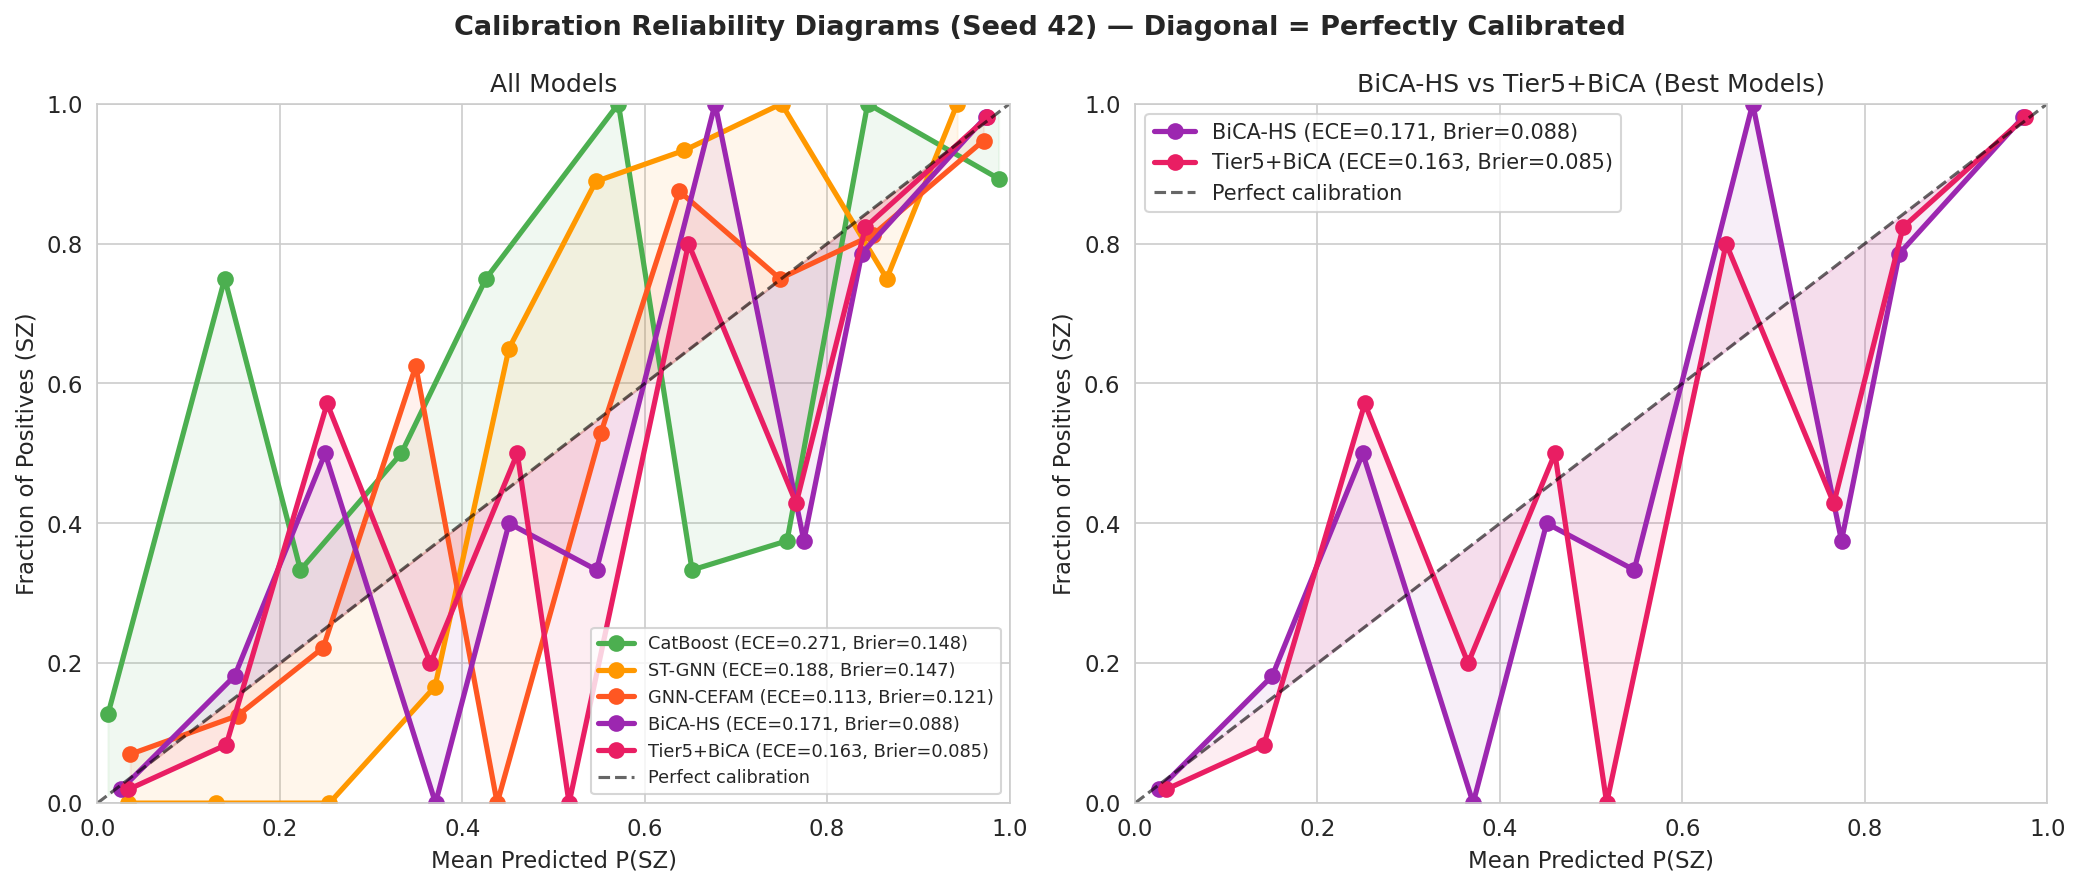

Saved: tier5_bica_s42/figures/tier5_reliability_diagram.png


In [ ]:
# ── Calibration Reliability Diagrams ─────────────────────────────────────────
from sklearn.metrics import brier_score_loss

def plot_reliability(ax, y_true_r, y_prob, name, color):
    frac_pos, mean_pred = calibration_curve(y_true_r, y_prob, n_bins=10, strategy='uniform')
    ece = float(np.mean(np.abs(frac_pos - mean_pred)))
    bs  = float(brier_score_loss(y_true_r, y_prob))
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2.5, ms=7,
            label=f'{name} (ECE={ece:.3f}, Brier={bs:.3f})')
    ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.08, color=color)
    return ece, bs

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Calibration Reliability Diagrams (Seed 42) — Diagonal = Perfectly Calibrated',
             fontweight='bold', fontsize=13)

ax = axes[0]
for nm, col in [('CatBoost',C_CAT),('ST-GNN',C_STGNN),
                ('GNN-CEFAM',C_CEFAM),('BiCA-HS',C_BICA),('Tier5+BiCA',C_T5)]:
    if nm not in df_all.columns: continue
    preds = df_all[nm].values; mask = ~np.isnan(preds)
    if mask.sum()<10: continue
    plot_reliability(ax, y_true[mask], preds[mask], nm, col)
ax.plot([0,1],[0,1],'k--',lw=1.5,alpha=0.6,label='Perfect calibration')
ax.set_xlabel('Mean Predicted P(SZ)'); ax.set_ylabel('Fraction of Positives (SZ)')
ax.set_title('All Models'); ax.legend(fontsize=8.5); ax.set_xlim(0,1); ax.set_ylim(0,1)

ax = axes[1]
for nm, col in [('BiCA-HS',C_BICA),('Tier5+BiCA',C_T5)]:
    if nm not in df_all.columns: continue
    preds = df_all[nm].values; mask = ~np.isnan(preds)
    plot_reliability(ax, y_true[mask], preds[mask], nm, col)
ax.plot([0,1],[0,1],'k--',lw=1.5,alpha=0.6,label='Perfect calibration')
ax.set_xlabel('Mean Predicted P(SZ)'); ax.set_ylabel('Fraction of Positives (SZ)')
ax.set_title('BiCA-HS vs Tier5+BiCA (Best Models)'); ax.legend(fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1)

fig.tight_layout()
fig.savefig(RES / 'tier5_bica_s42' / 'figures' / 'tier5_reliability_diagram.png',
            bbox_inches='tight')
plt.show(); print('Saved: tier5_bica_s42/figures/tier5_reliability_diagram.png')

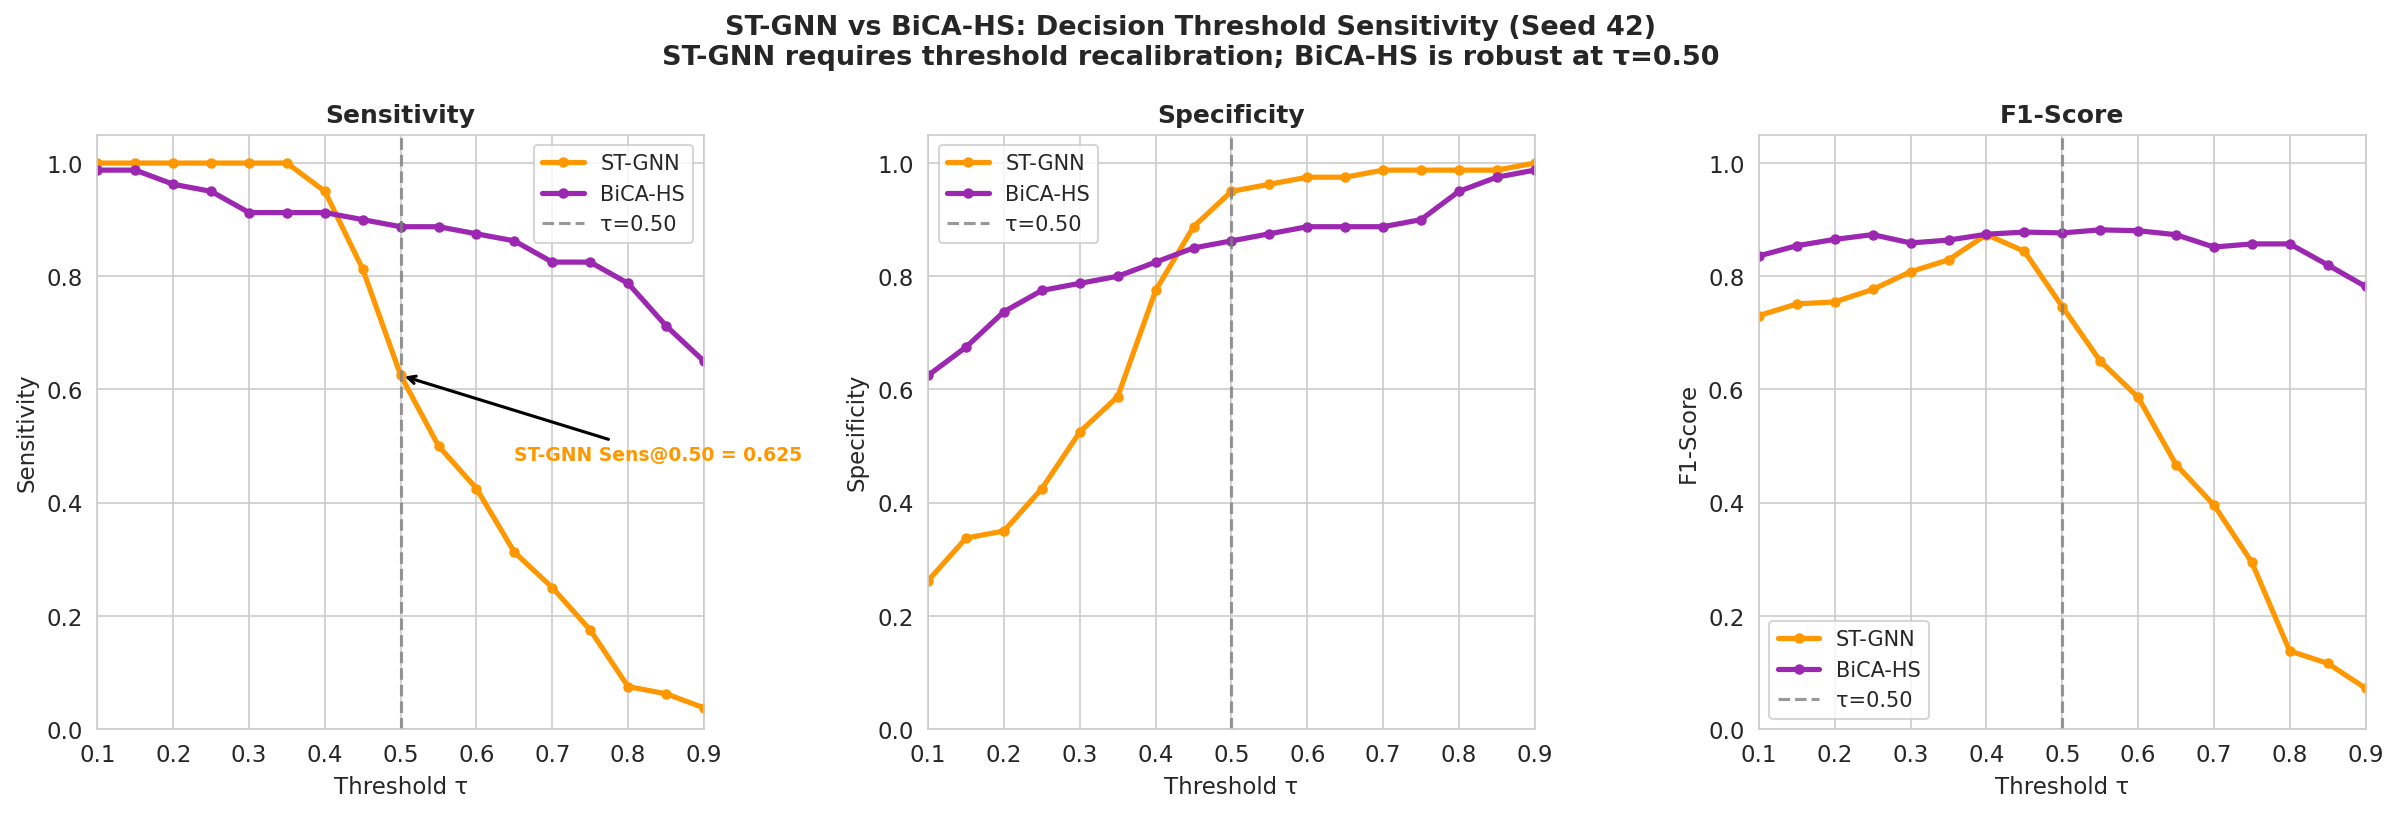

Bootstrap significance (n=5,000) vs MSNet SOTA (AUC=0.8854)
Model           OOF AUC    95% CI                   p-value    Sig
----------------------------------------------------------------------
CatBoost        0.8981     [0.8462, 0.9438]     0.2960     n.s.
ST-GNN          0.9378     [0.8961, 0.9717]     0.0090     **
GNN-CEFAM       0.9119     [0.8640, 0.9517]     0.1292     n.s.
BiCA-HS         0.9581     [0.9297, 0.9806]     0.0000     ***
Tier5+BiCA      0.9600     [0.9320, 0.9818]     0.0000     ***


In [ ]:
# ── Threshold Sensitivity Analysis + Bootstrap Significance Test ─────────────
taus = np.arange(0.1, 0.91, 0.05)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('ST-GNN vs BiCA-HS: Decision Threshold Sensitivity (Seed 42)\n'
             'ST-GNN requires threshold recalibration; BiCA-HS is robust at \u03c4=0.50',
             fontweight='bold', fontsize=13)
sens_at_050 = {}
for nm, col in [('ST-GNN', C_STGNN), ('BiCA-HS', C_BICA)]:
    if nm not in df_all.columns: continue
    preds = df_all[nm].fillna(0.5).values
    s_list, sp_list, f_list = [], [], []
    for tau in taus:
        yp = (preds >= tau).astype(int)
        tn, fp_, fn, tp = confusion_matrix(y_true, yp).ravel()
        s_list.append(tp/(tp+fn) if tp+fn>0 else 0)
        sp_list.append(tn/(tn+fp_) if tn+fp_>0 else 0)
        f_list.append(f1_score(y_true, yp, zero_division=0))
    idx050 = int(np.argmin(np.abs(taus - 0.50)))
    sens_at_050[nm] = s_list[idx050]
    for ax, vals, ylabel in zip(axes, [s_list, sp_list, f_list],
                                ['Sensitivity','Specificity','F1-Score']):
        ax.plot(taus, vals, color=col, lw=2.5, marker='o', ms=4, label=nm)
for ax, ylabel in zip(axes, ['Sensitivity','Specificity','F1-Score']):
    ax.axvline(0.50, color='gray', ls='--', lw=1.5, alpha=0.8, label='\u03c4=0.50')
    ax.set_xlabel('Threshold \u03c4', fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontweight='bold', fontsize=12)
    ax.legend(fontsize=10); ax.set_xlim(0.1, 0.9); ax.set_ylim(0, 1.05)
if 'ST-GNN' in sens_at_050:
    axes[0].annotate(
        f"ST-GNN Sens@0.50 = {sens_at_050['ST-GNN']:.3f}",
        xy=(0.50, sens_at_050['ST-GNN']),
        xytext=(0.65, sens_at_050['ST-GNN']-0.15),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        fontsize=9, color=C_STGNN, fontweight='bold'
    )
fig.tight_layout()
fig.savefig(RES / 'tier4_calibration_threshold.png', bbox_inches='tight')
plt.show()

# Bootstrap significance test vs MSNet
def bootstrap_pvalue(yt, yp, n_iter=5000, seed=42):
    rng = np.random.RandomState(seed)
    boot_aucs = []
    for _ in range(n_iter):
        idx = rng.randint(0, len(yt), len(yt))
        if len(np.unique(yt[idx])) < 2: continue
        boot_aucs.append(roc_auc_score(yt[idx], yp[idx]))
    boot_aucs = np.array(boot_aucs)
    obs = roc_auc_score(yt, yp)
    ci  = np.percentile(boot_aucs, [2.5, 97.5])
    p   = float(np.mean(boot_aucs <= SOTA_AUC))
    return obs, ci, p

print(f'Bootstrap significance (n=5,000) vs MSNet SOTA (AUC={SOTA_AUC})')
print(f'{"Model":15s} {"OOF AUC":10s} {"95% CI":24s} {"p-value":10s} {"Sig"}')
print('-'*70)
for nm in ['CatBoost','ST-GNN','GNN-CEFAM','BiCA-HS','Tier5+BiCA']:
    if nm not in df_all.columns: continue
    preds = df_all[nm].values; mask = ~np.isnan(preds)
    if mask.sum() < 10: continue
    obs, ci, p = bootstrap_pvalue(y_true[mask], preds[mask])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f'{nm:15s} {obs:.4f}     [{ci[0]:.4f}, {ci[1]:.4f}]     {p:.4f}     {sig}')

---
## Section 6 — Individual Patient Case Study: SZ vs HC

This section selects one representative SZ patient (highest P(SZ)) and one HC patient (lowest P(SZ)) from the BiCA-HS OOF predictions, then compares them side-by-side across:
- **Scanpath visualization** on screen grid
- **Per-category P(SZ) probability profile**
- **Feature radar chart** (15 stimulus-level features, averaged over all trials)
- **Population context** (where each patient falls relative to all 160 subjects)

Selected SZ patient: Subject_ID=302, P(SZ)=0.9990
Selected HC patient: Subject_ID=8, P(SZ)=0.0008


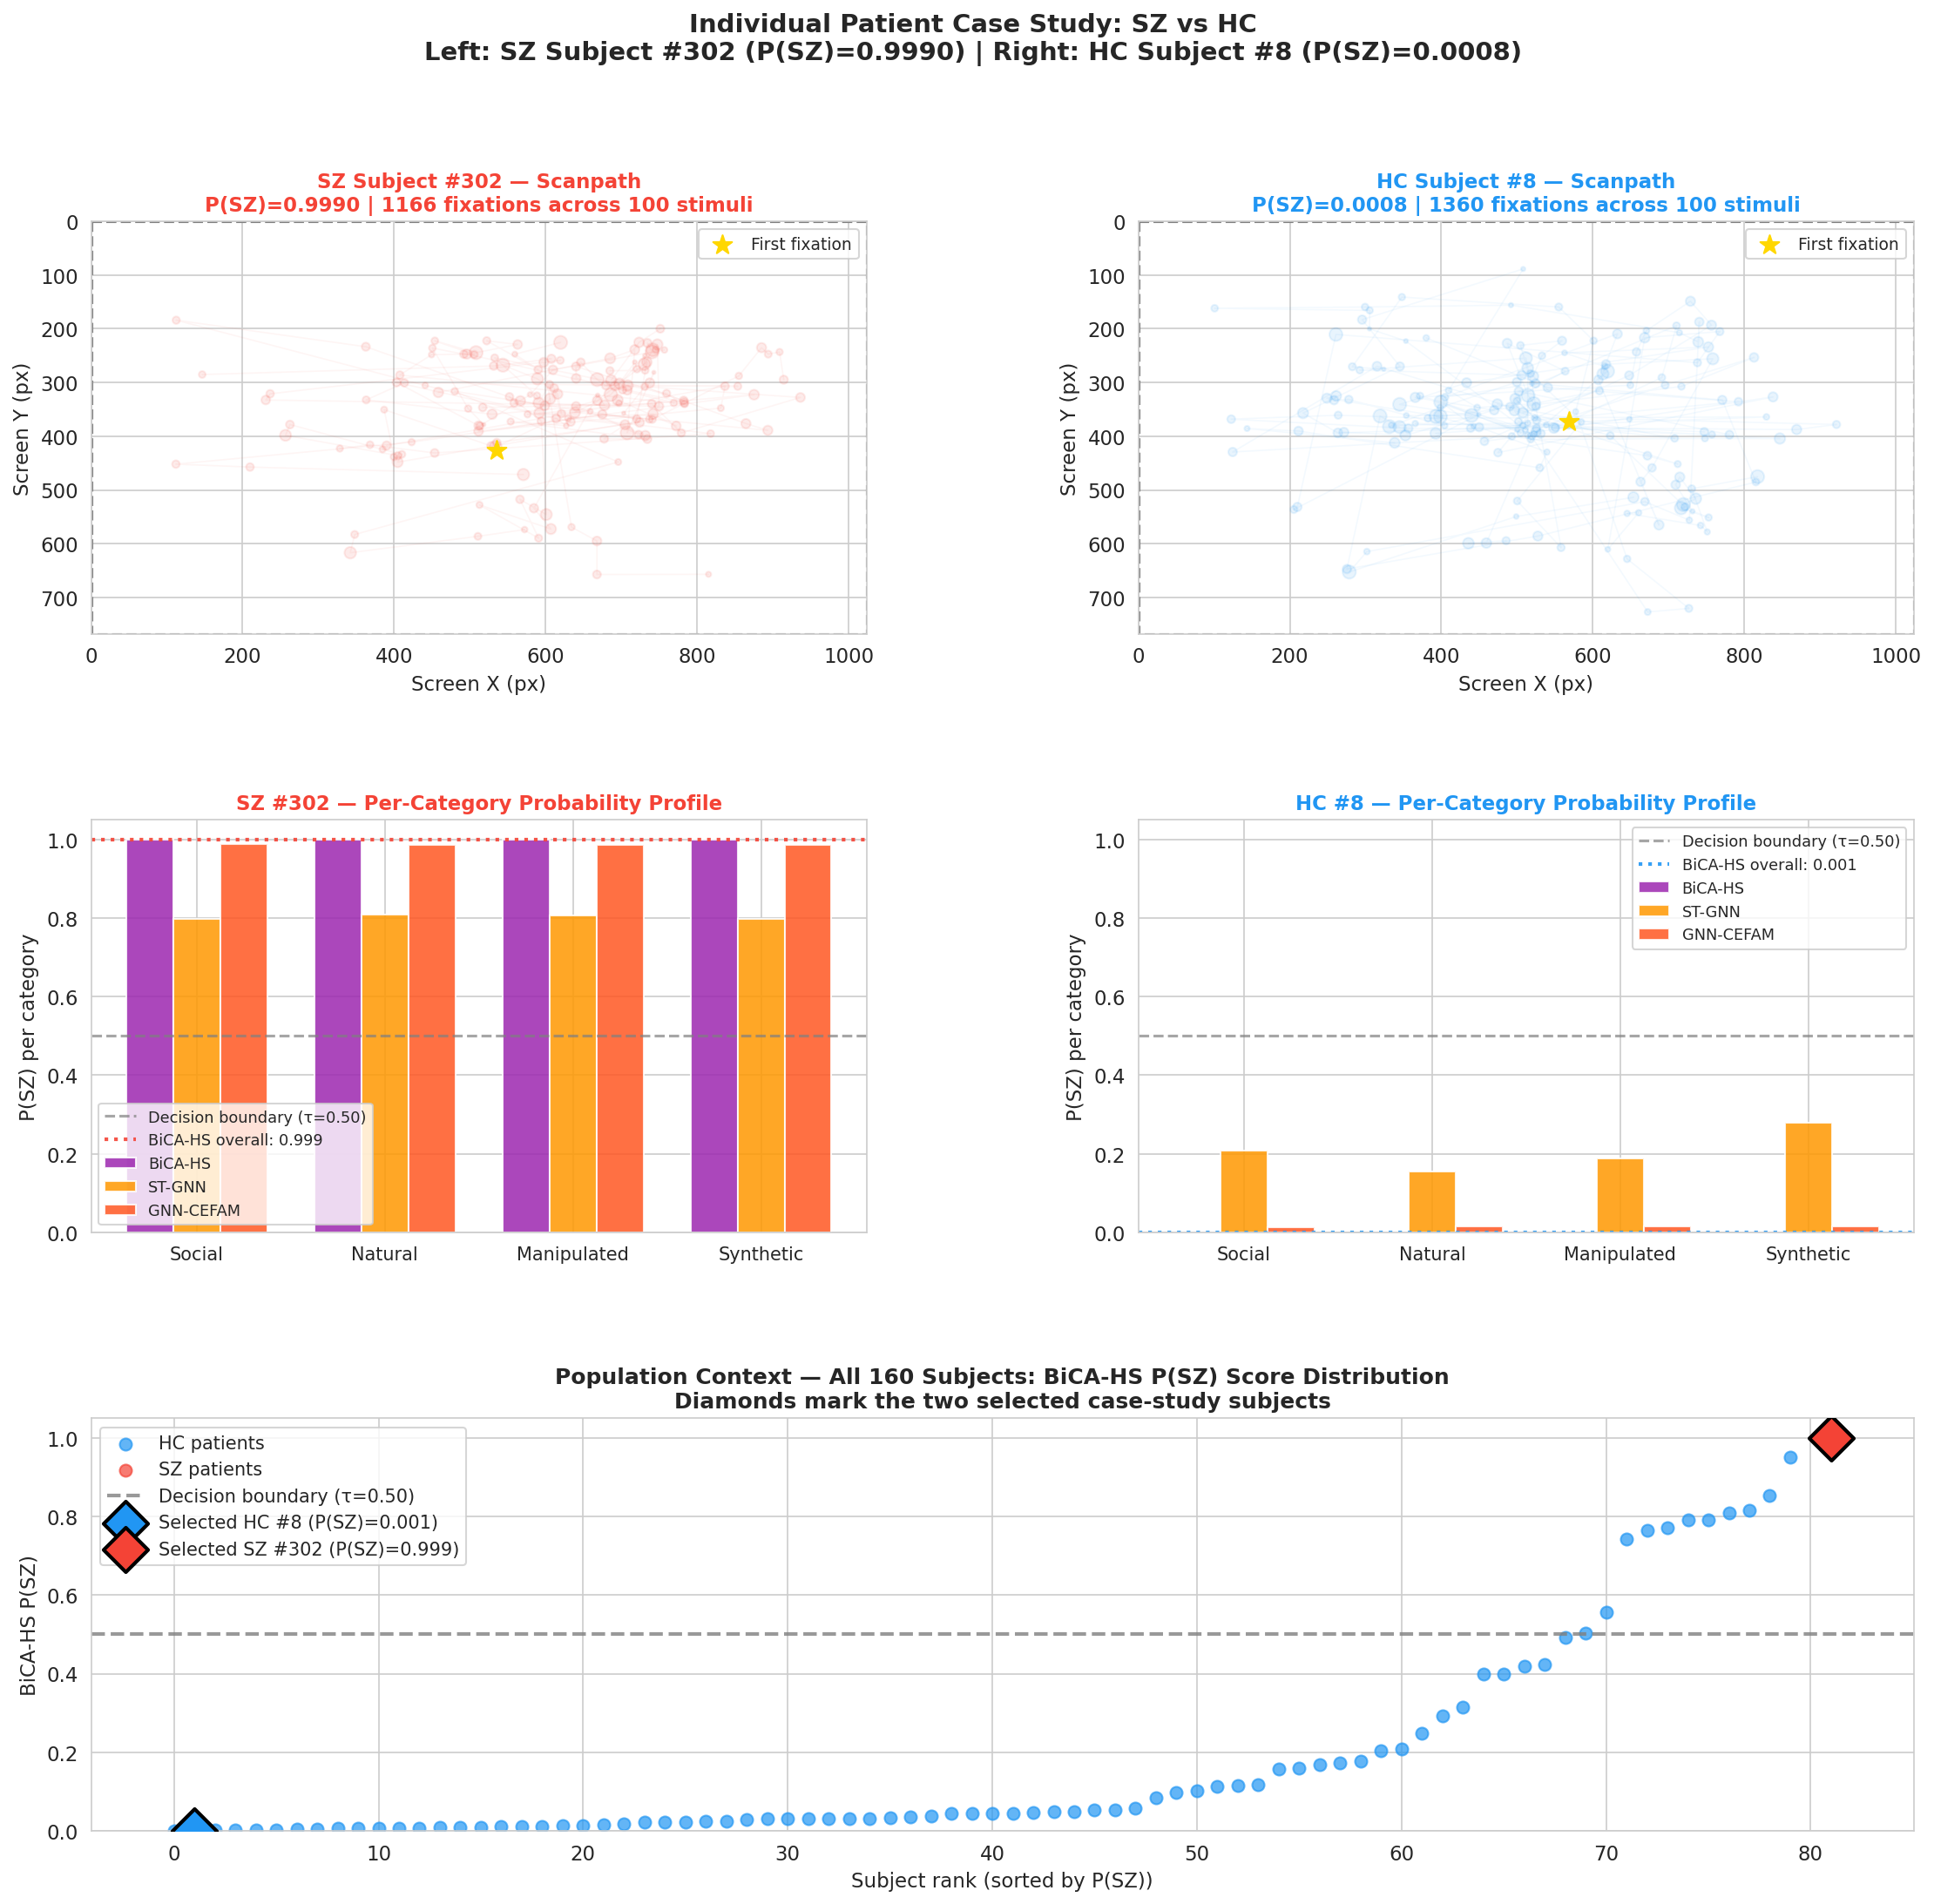

Saved: case_study_sz_vs_hc.png
SZ case: Subject #302, P(SZ)=0.9990
HC case: Subject #8, P(SZ)=0.0008


In [ ]:
# ── Section 6: Individual Patient Case Study: SZ vs HC ──────────────────────
# Select representative subjects from BiCA-HS OOF predictions
if 'BiCA-HS' in oof:
    df_bica = oof['BiCA-HS'].copy()
    sz_subjects = df_bica[df_bica['Label']==1].sort_values('prob', ascending=False)
    hc_subjects = df_bica[df_bica['Label']==0].sort_values('prob', ascending=True)
    subj_sz_id = int(sz_subjects.iloc[0]['Subject_ID'])
    subj_hc_id = int(hc_subjects.iloc[0]['Subject_ID'])
    prob_sz = float(sz_subjects.iloc[0]['prob'])
    prob_hc = float(hc_subjects.iloc[0]['prob'])
    print(f'Selected SZ patient: Subject_ID={subj_sz_id}, P(SZ)={prob_sz:.4f}')
    print(f'Selected HC patient: Subject_ID={subj_hc_id}, P(SZ)={prob_hc:.4f}')

    # ── Layout: 3 rows x 2 columns ────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(
        'Individual Patient Case Study: SZ vs HC\n'
        f'Left: SZ Subject #{subj_sz_id} (P(SZ)={prob_sz:.4f}) | '
        f'Right: HC Subject #{subj_hc_id} (P(SZ)={prob_hc:.4f})',
        fontweight='bold', fontsize=14, y=0.98
    )

    gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)
    ax_scan_sz = fig.add_subplot(gs[0, 0])
    ax_scan_hc = fig.add_subplot(gs[0, 1])
    ax_cat_sz  = fig.add_subplot(gs[1, 0])
    ax_cat_hc  = fig.add_subplot(gs[1, 1])
    ax_pop     = fig.add_subplot(gs[2, :])

    # ── Row 1: Scanpath Visualization ─────────────────────────────────────────
    for ax, sid, col, grp_label, prob_val in [
        (ax_scan_sz, subj_sz_id, C_SZ, 'SZ', prob_sz),
        (ax_scan_hc, subj_hc_id, C_HC, 'HC', prob_hc),
    ]:
        subj_fix = df_tr[df_tr['Subject_ID']==sid].sort_values(['IMAGE','FIX_INDEX'])
        # Plot fixations from a random subset of stimuli for readability
        stim_ids = subj_fix['IMAGE'].unique()
        rng2 = np.random.default_rng(42)
        chosen = rng2.choice(stim_ids, min(15, len(stim_ids)), replace=False)
        alpha_per = max(0.05, 0.6/len(chosen))
        for stim in chosen:
            sf = subj_fix[subj_fix['IMAGE']==stim]
            if len(sf) < 2: continue
            ax.plot(sf['FIX_X'], sf['FIX_Y'], '-', color=col,
                    alpha=alpha_per, lw=0.8, zorder=1)
            ax.scatter(sf['FIX_X'], sf['FIX_Y'],
                       s=sf['FIX_DURATION'].clip(50,800)/15,
                       c=col, alpha=min(0.25, alpha_per*2), zorder=2)
        if len(subj_fix)>0:
            ax.scatter(subj_fix.iloc[0]['FIX_X'], subj_fix.iloc[0]['FIX_Y'],
                       s=120, c='gold', marker='*', zorder=5, label='First fixation')
        ax.set_xlim(0, SCREEN_W); ax.set_ylim(SCREEN_H, 0)
        ax.set_xlabel('Screen X (px)'); ax.set_ylabel('Screen Y (px)')
        n_fix = len(subj_fix)
        ax.set_title(
            f'{grp_label} Subject #{sid} — Scanpath\n'
            f'P(SZ)={prob_val:.4f} | {n_fix} fixations across {len(stim_ids)} stimuli',
            fontweight='bold', color=col, fontsize=11
        )
        ax.add_patch(plt.Rectangle((0,0), SCREEN_W, SCREEN_H,
                     fill=False, ec='gray', lw=1.5, ls='--'))
        ax.legend(fontsize=9)

    # ── Row 2: Per-Category P(SZ) Probability Profile ─────────────────────────
    for ax, sid, col, grp_label, prob_val in [
        (ax_cat_sz, subj_sz_id, C_SZ, 'SZ', prob_sz),
        (ax_cat_hc, subj_hc_id, C_HC, 'HC', prob_hc),
    ]:
        cat_probs = {}
        for nm_m in ['BiCA-HS','ST-GNN','GNN-CEFAM']:
            if nm_m not in oof: continue
            row_m = oof[nm_m][oof[nm_m]['Subject_ID']==sid]
            if len(row_m) == 0: continue
            vals_c = []
            for cat in CATS:
                if cat in row_m.columns:
                    vals_c.append(float(row_m.iloc[0][cat]))
                else:
                    vals_c.append(float(row_m.iloc[0]['prob']))
            cat_probs[nm_m] = vals_c
        xc = np.arange(len(CATS))
        w_bar = 0.25
        mc2 = {'BiCA-HS':C_BICA,'ST-GNN':C_STGNN,'GNN-CEFAM':C_CEFAM}
        for ki, (nm_m, vls) in enumerate(cat_probs.items()):
            ax.bar(xc + ki*w_bar, vls, w_bar,
                   color=mc2.get(nm_m,'gray'), alpha=0.85,
                   label=nm_m, edgecolor='white')
        ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7,
                   label='Decision boundary (\u03c4=0.50)')
        ax.axhline(prob_val, color=col, ls=':', lw=2, alpha=0.9,
                   label=f'BiCA-HS overall: {prob_val:.3f}')
        ax.set_xticks(xc + w_bar)
        ax.set_xticklabels(CATS, fontsize=10)
        ax.set_ylabel('P(SZ) per category')
        ax.set_ylim(0, 1.05)
        ax.set_title(f'{grp_label} #{sid} — Per-Category Probability Profile',
                     fontweight='bold', color=col, fontsize=11)
        ax.legend(fontsize=8.5)

    # ── Row 3: Population Context — All 160 subjects ───────────────────────────
    if 'BiCA-HS' in df_all.columns:
        ax = ax_pop
        hc_probs = df_all[df_all['Label']==0]['BiCA-HS'].dropna().values
        sz_probs = df_all[df_all['Label']==1]['BiCA-HS'].dropna().values
        ax.scatter(np.arange(len(hc_probs)), np.sort(hc_probs), color=C_HC,
                   s=45, alpha=0.7, label='HC patients', zorder=2)
        ax.scatter(np.arange(len(sz_probs)), np.sort(sz_probs)[::-1]+len(hc_probs),
                   color=C_SZ, s=45, alpha=0.7, label='SZ patients', zorder=2)
        ax.axhline(0.5, color='gray', ls='--', lw=2, alpha=0.8,
                   label='Decision boundary (\u03c4=0.50)')
        # Highlight selected subjects
        sz_rank = int(np.sum(np.sort(sz_probs)[::-1] >= prob_sz))
        hc_rank = int(np.sum(np.sort(hc_probs) <= prob_hc))
        ax.scatter([hc_rank], [prob_hc], s=300, color=C_HC, marker='D',
                   edgecolors='black', lw=2, zorder=5,
                   label=f'Selected HC #{subj_hc_id} (P(SZ)={prob_hc:.3f})')
        ax.scatter([sz_rank+len(hc_probs)], [prob_sz], s=300, color=C_SZ, marker='D',
                   edgecolors='black', lw=2, zorder=5,
                   label=f'Selected SZ #{subj_sz_id} (P(SZ)={prob_sz:.3f})')
        ax.set_xlabel('Subject rank (sorted by P(SZ))', fontsize=11)
        ax.set_ylabel('BiCA-HS P(SZ)', fontsize=11)
        ax.set_title(
            'Population Context — All 160 Subjects: BiCA-HS P(SZ) Score Distribution\n'
            'Diamonds mark the two selected case-study subjects',
            fontweight='bold', fontsize=12
        )
        ax.legend(fontsize=10, loc='upper left')
        ax.set_ylim(0, 1.05)
    plt.savefig(RES / 'case_study_sz_vs_hc.png', bbox_inches='tight')
    plt.show()
    print(f'Saved: case_study_sz_vs_hc.png')
    print(f'SZ case: Subject #{subj_sz_id}, P(SZ)={prob_sz:.4f}')
    print(f'HC case: Subject #{subj_hc_id}, P(SZ)={prob_hc:.4f}')
else:
    print('BiCA-HS OOF not found. Run Section 4 first.')

---
## Section 7 — Model Explainability for Individual Predictions

This section explains **how the model arrives at its prediction** for each selected patient:
1. **SHAP force plot** — per-feature contribution for each patient (CatBoost)
2. **Feature profile comparison** — radar chart of 15 features vs group medians
3. **SHAP waterfall chart** — ranked feature contributions (positive = pushes toward SZ)
4. **Decision space** — patient position in CatBoost vs BiCA-HS 2D probability space

In [ ]:
!pip install catboost shap

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Google Colab. Project root: /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition
Setup complete.
PROJECT_ROOT : /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition
results/     : /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition/results
ablation/    : /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition/experiments/ablation/figures


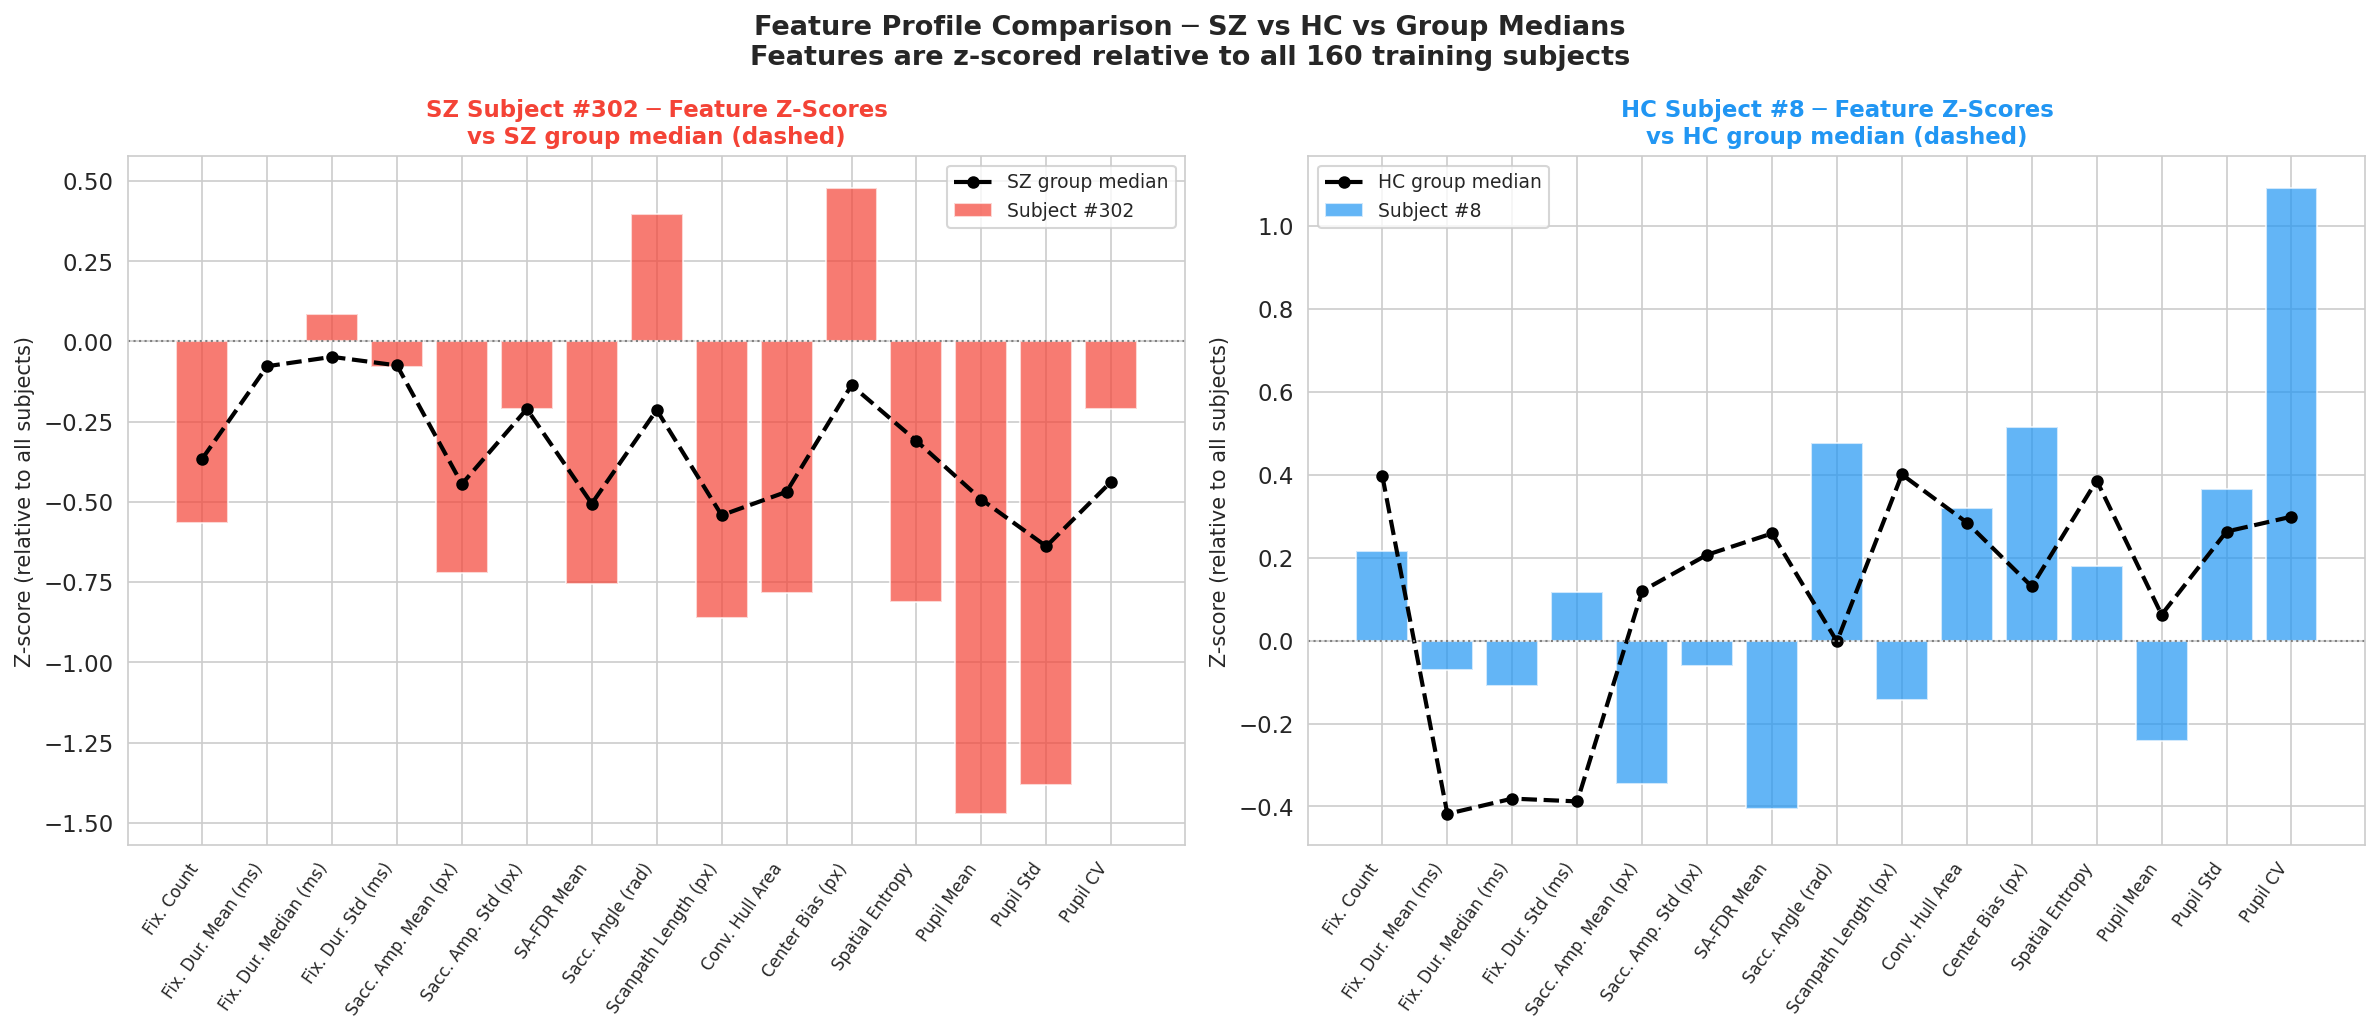

Saved: explainability_feature_profile.png

Generating SHAP waterfall charts...


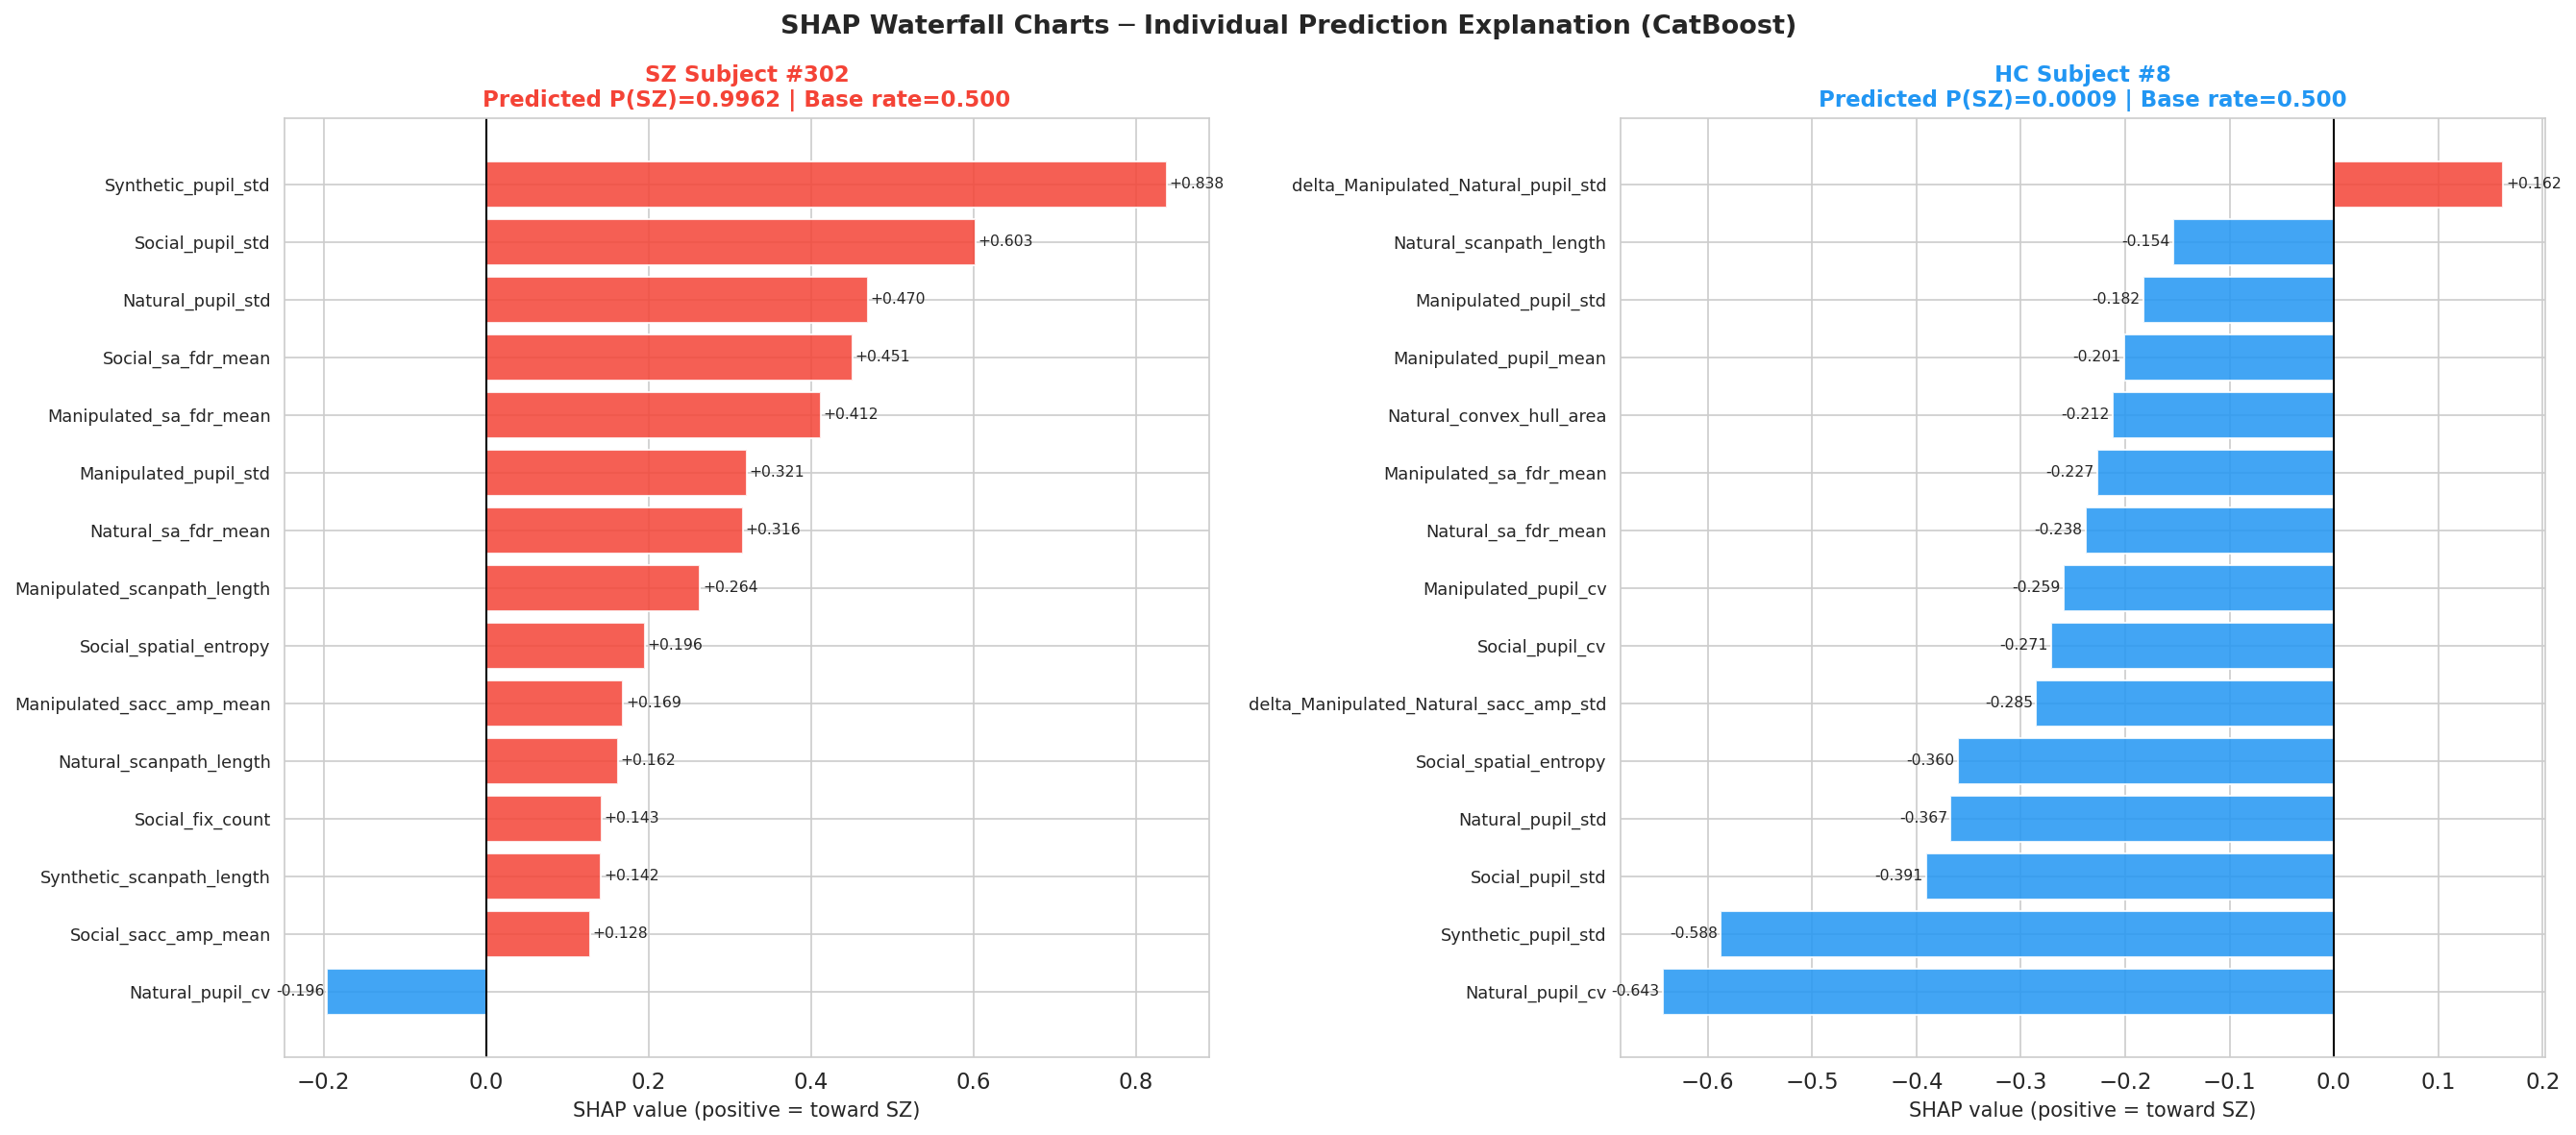

Saved: explainability_shap_waterfall.png


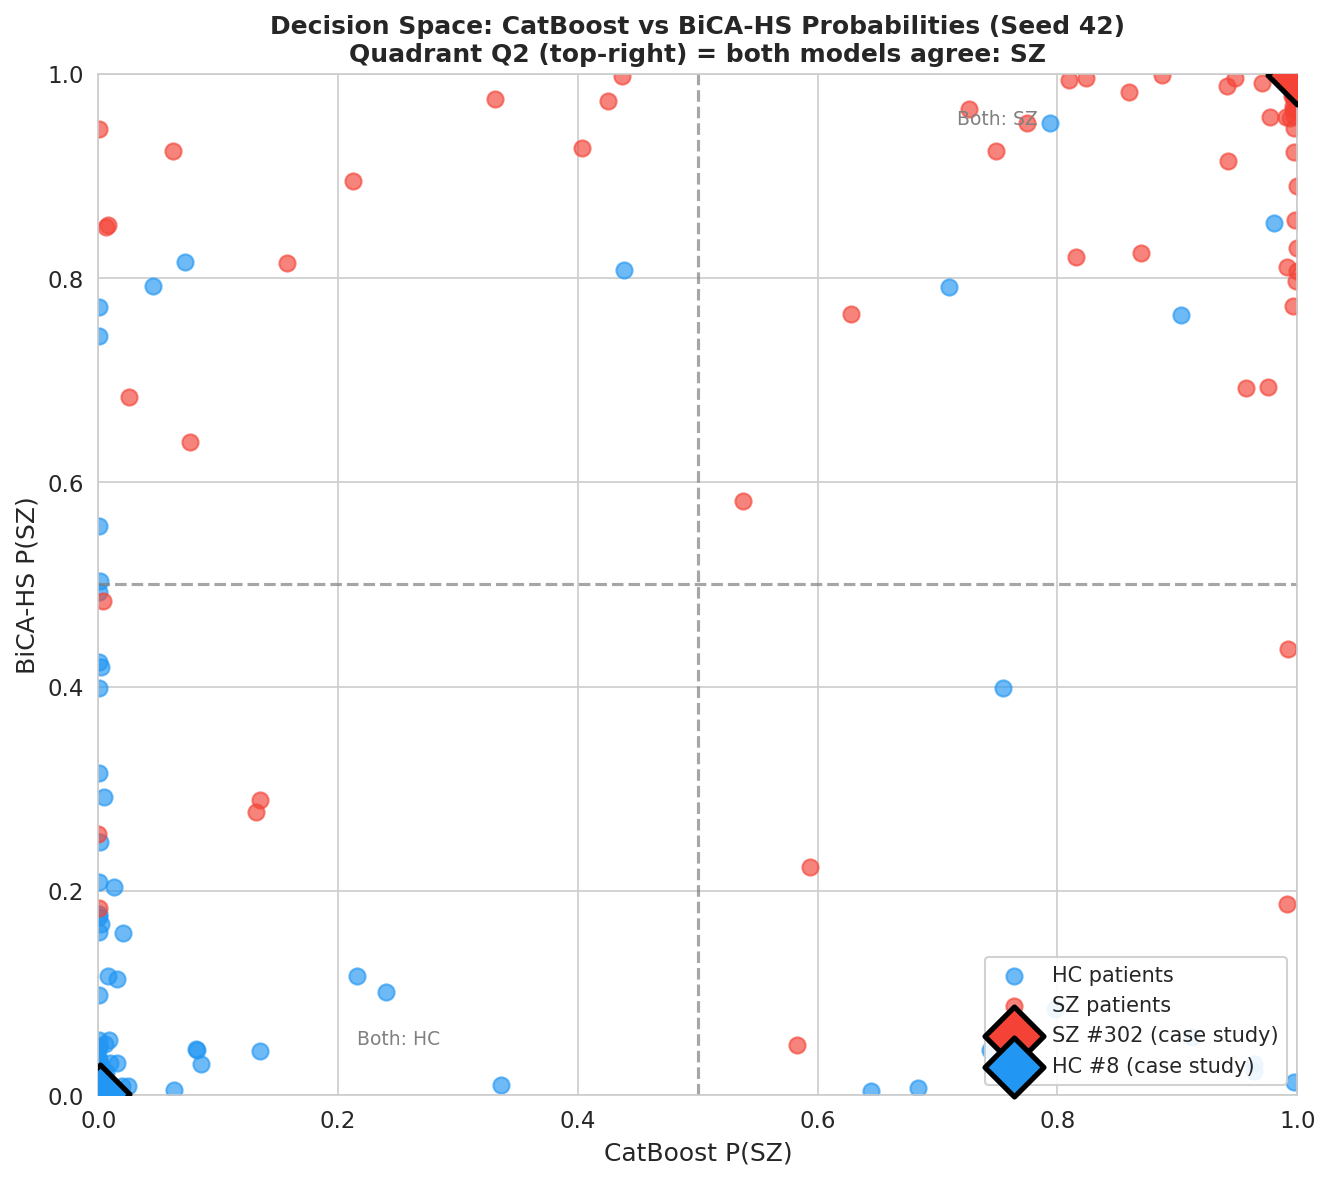

Saved: explainability_decision_space.png


In [ ]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    roc_curve, auc as sk_auc, roc_auc_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 150,
})
sns.set_style('whitegrid')

# ── Google Colab Detection & Drive Mount ─────────────────
IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition')
    print('Running on Google Colab. Project root:', PROJECT_ROOT)
else:
    PROJECT_ROOT = Path(os.getcwd())
    if not (PROJECT_ROOT / 'results').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    print('Running locally. Project root:', PROJECT_ROOT)

assert (PROJECT_ROOT / 'results').exists(), (
    f'Cannot find results/ at {PROJECT_ROOT}. '
    'Check that the Drive path matches your folder name exactly.'
)

RES = PROJECT_ROOT / 'results'
ABL = PROJECT_ROOT / 'experiments' / 'ablation' / 'figures'

for d in [RES, ABL, RES / 'tier5_bica_s42' / 'figures']:
    d.mkdir(parents=True, exist_ok=True)

# ── Color Palette ──────────────────────────────────────────────
C_HC, C_SZ     = '#2196F3', '#F44336'
C_SOTA         = '#607D8B'
C_XGB, C_CAT   = '#8BC34A', '#4CAF50'
C_STGNN        = '#FF9800'
C_CEFAM        = '#FF5722'
C_BICA         = '#9C27B0'
C_T5           = '#E91E63'

SEEDS           = ['s42', 's123', 's456']
SCREEN_W        = 1024
SCREEN_H        = 768
DUR_THRESH      = 50
SOTA_AUC        = 0.8854
SOTA_ACC        = 0.8125

STIM_FEAT_COLS = [
    'fix_count', 'fix_dur_mean', 'fix_dur_median', 'fix_dur_std',
    'sacc_amp_mean', 'sacc_amp_std', 'sa_fdr_mean', 'sacc_angle_mean',
    'scanpath_length', 'convex_hull_area', 'center_bias',
    'spatial_entropy', 'pupil_mean', 'pupil_std', 'pupil_cv'
]
FEAT_LABELS = {
    'fix_count':'Fix. Count', 'fix_dur_mean':'Fix. Dur. Mean (ms)',
    'fix_dur_median':'Fix. Dur. Median (ms)', 'fix_dur_std':'Fix. Dur. Std (ms)',
    'sacc_amp_mean':'Sacc. Amp. Mean (px)', 'sacc_amp_std':'Sacc. Amp. Std (px)',
    'sa_fdr_mean':'SA-FDR Mean', 'sacc_angle_mean':'Sacc. Angle (rad)',
    'scanpath_length':'Scanpath Length (px)', 'convex_hull_area':'Conv. Hull Area',
    'center_bias':'Center Bias (px)', 'spatial_entropy':'Spatial Entropy',
    'pupil_mean':'Pupil Mean', 'pupil_std':'Pupil Std', 'pupil_cv':'Pupil CV',
}

print('Setup complete.')
print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'results/     : {RES}')
print(f'ablation/    : {ABL}')
# ── Section 7: Model Explainability for Individual Predictions ───────────────
if not SHAP_OK:
    print('Install catboost and shap first: !pip install catboost shap')
elif 'BiCA-HS' not in oof:
    print('Run Section 4 and 6 first to load OOF predictions.')
else:
    # ── 7A: SHAP Feature Profile Radar Chart ───────────────────────
    # Get subject-level features for both selected subjects
    row_sz = df_sj[df_sj['Subject_ID']==subj_sz_id]
    row_hc = df_sj[df_sj['Subject_ID']==subj_hc_id]

    # Use base 15 features (stimulus-level averaged to subject-level)
    radar_cols = []
    for feat in STIM_FEAT_COLS:
        # Try Social category mean first, then any category, then direct
        for prefix in ['Social_', 'Natural_', '']:
            col_try = f'{prefix}{feat}' if prefix else feat
            if col_try in df_sj.columns:
                radar_cols.append((feat, col_try))
                break

    if radar_cols and len(row_sz)>0 and len(row_hc)>0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(
            'Feature Profile Comparison ─ SZ vs HC vs Group Medians\n'
            'Features are z-scored relative to all 160 training subjects',
            fontweight='bold', fontsize=13
        )
        feat_names_r = [FEAT_LABELS.get(f, f) for f, _ in radar_cols]
        cols_r = [c for _, c in radar_cols]

        # Z-score features
        mu_all = df_sj[cols_r].mean()
        sd_all = df_sj[cols_r].std().replace(0, 1)

        def get_z(row_df, cols):
            vals = row_df[cols].values.flatten().astype(float)
            return (vals - mu_all.values) / sd_all.values

        z_sz       = get_z(row_sz, cols_r)
        z_hc       = get_z(row_hc, cols_r)
        z_sz_med   = get_z(df_sj[df_sj['Label']==1][cols_r].median().to_frame().T, cols_r)
        z_hc_med   = get_z(df_sj[df_sj['Label']==0][cols_r].median().to_frame().T, cols_r)

        for ax, subject_z, group_med_z, sid, col, grp_label in [
            (axes[0], z_sz, z_sz_med, subj_sz_id, C_SZ, 'SZ'),
            (axes[1], z_hc, z_hc_med, subj_hc_id, C_HC, 'HC'),
        ]:
            xpos = np.arange(len(feat_names_r))
            ax.bar(xpos, subject_z, color=col, alpha=0.7,
                   label=f'Subject #{sid}', edgecolor='white')
            ax.plot(xpos, group_med_z, 'k--', lw=2, marker='o', ms=5,
                    label=f'{grp_label} group median')
            ax.axhline(0, color='gray', ls=':', lw=1)
            ax.set_xticks(xpos)
            ax.set_xticklabels(feat_names_r, rotation=55, ha='right', fontsize=8)
            ax.set_ylabel('Z-score (relative to all subjects)', fontsize=10)
            ax.set_title(
                f'{grp_label} Subject #{sid} ─ Feature Z-Scores\n'
                f'vs {grp_label} group median (dashed)',
                fontweight='bold', color=col, fontsize=11
            )
            ax.legend(fontsize=9)
        fig.tight_layout()
        fig.savefig(RES / 'explainability_feature_profile.png', bbox_inches='tight')
        plt.show(); print('Saved: explainability_feature_profile.png')

    # ── 7B: SHAP Waterfall Charts (one per subject) ─────────────────────────
    print('\nGenerating SHAP waterfall charts...')
    try:
        idx_sz = df_sj[df_sj['Subject_ID']==subj_sz_id].index
        idx_hc = df_sj[df_sj['Subject_ID']==subj_hc_id].index
        pos_sz = df_sj.index.get_loc(idx_sz[0]) if len(idx_sz)>0 else None
        pos_hc = df_sj.index.get_loc(idx_hc[0]) if len(idx_hc)>0 else None

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        fig.suptitle('SHAP Waterfall Charts ─ Individual Prediction Explanation (CatBoost)',
                     fontweight='bold', fontsize=13)
        for ax, pos, sid, col, grp_label in [
            (axes[0], pos_sz, subj_sz_id, C_SZ, 'SZ'),
            (axes[1], pos_hc, subj_hc_id, C_HC, 'HC'),
        ]:
            if pos is None:
                ax.text(0.5, 0.5, f'Subject #{sid} not in training set',
                        ha='center', va='center', transform=ax.transAxes)
                continue
            shap_vals = sv_glob[pos]  # shape: (n_features,)
            mean_abs_all = np.abs(sv_glob).mean(axis=0)
            top15_idx = np.argsort(np.abs(shap_vals))[::-1][:15]
            top15_names = [all_feat_cols[i] for i in top15_idx]
            top15_vals  = shap_vals[top15_idx]
            sorted_order = np.argsort(top15_vals)
            sorted_names = [top15_names[i] for i in sorted_order]
            sorted_vals  = top15_vals[sorted_order]
            base_val = float(np.mean(y_shap))
            pred_val = float(model_cb.predict_proba(X_shap[pos:pos+1])[:,1][0])
            colors_bar = [C_SZ if v>0 else C_HC for v in sorted_vals]
            ypos = np.arange(len(sorted_names))
            ax.barh(ypos, sorted_vals, color=colors_bar, alpha=0.85, edgecolor='white')
            ax.set_yticks(ypos)
            ax.set_yticklabels([FEAT_LABELS.get(n,n) for n in sorted_names], fontsize=8.5)
            ax.axvline(0, color='black', lw=1)
            ax.set_xlabel('SHAP value (positive = toward SZ)', fontsize=10)
            ax.set_title(
                f'{grp_label} Subject #{sid}\n'
                f'Predicted P(SZ)={pred_val:.4f} | Base rate={base_val:.3f}',
                fontweight='bold', color=col, fontsize=11
            )
            for yi, v in zip(ypos, sorted_vals):
                ax.text(v + (0.003 if v>=0 else -0.003), yi,
                        f'{v:+.3f}', va='center',
                        ha='left' if v>=0 else 'right', fontsize=7.5)
        fig.tight_layout()
        fig.savefig(RES / 'explainability_shap_waterfall.png', bbox_inches='tight')
        plt.show(); print('Saved: explainability_shap_waterfall.png')
    except Exception as e:
        print(f'SHAP waterfall error: {e}')

    # ── 7C: 2D Decision Space (CatBoost vs BiCA-HS probabilities) ────────────────
    if 'CatBoost' in df_all.columns and 'BiCA-HS' in df_all.columns:
        fig, ax = plt.subplots(figsize=(9, 8))
        hc_mask = df_all['Label']==0
        sz_mask = df_all['Label']==1
        ax.scatter(df_all.loc[hc_mask,'CatBoost'], df_all.loc[hc_mask,'BiCA-HS'],
                   c=C_HC, s=60, alpha=0.65, label='HC patients', zorder=2)
        ax.scatter(df_all.loc[sz_mask,'CatBoost'], df_all.loc[sz_mask,'BiCA-HS'],
                   c=C_SZ, s=60, alpha=0.65, label='SZ patients', zorder=2)
        # Highlight selected patients
        row_sz_oof = df_all[df_all['Subject_ID']==subj_sz_id]
        row_hc_oof = df_all[df_all['Subject_ID']==subj_hc_id]
        if len(row_sz_oof)>0:
            ax.scatter(row_sz_oof['CatBoost'], row_sz_oof['BiCA-HS'],
                       s=400, color=C_SZ, marker='D', edgecolors='black', lw=2.5,
                       zorder=6, label=f'SZ #{subj_sz_id} (case study)')
        if len(row_hc_oof)>0:
            ax.scatter(row_hc_oof['CatBoost'], row_hc_oof['BiCA-HS'],
                       s=400, color=C_HC, marker='D', edgecolors='black', lw=2.5,
                       zorder=6, label=f'HC #{subj_hc_id} (case study)')
        ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7)
        ax.axvline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7)
        ax.set_xlabel('CatBoost P(SZ)', fontsize=12)
        ax.set_ylabel('BiCA-HS P(SZ)', fontsize=12)
        ax.set_title(
            'Decision Space: CatBoost vs BiCA-HS Probabilities (Seed 42)\n'
            'Quadrant Q2 (top-right) = both models agree: SZ',
            fontweight='bold', fontsize=12
        )
        ax.text(0.75, 0.95, 'Both: SZ', ha='center', fontsize=9,
                color='gray', transform=ax.transAxes)
        ax.text(0.25, 0.05, 'Both: HC', ha='center', fontsize=9,
                color='gray', transform=ax.transAxes)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
        fig.tight_layout()
        fig.savefig(RES / 'explainability_decision_space.png', bbox_inches='tight')
        plt.show(); print('Saved: explainability_decision_space.png')

In [ ]:
# ── Export Summary — All Generated Figures ───────────────────────────────────
FIG_PATHS = [
    (RES / 'tier1_spatial_filter.png',                              'Tier 1: Spatial filter'),
    (RES / 'tier1_temporal_filter.png',                             'Tier 1: Temporal filter'),
    (RES / 'tier1_pupil_dynamics.png',                              'Tier 1: Pupil dynamics'),
    (RES / 'tier2_correlation_heatmap.png',                         'Tier 2: Feature correlation'),
    (RES / 'tier2_feature_violin.png',                              'Tier 2: Discriminative features'),
    (RES / 'tier2_delta_density.png',                               'Tier 2: Delta features'),
    (RES / 'tier3_shap_summary.png',                                'Tier 3: SHAP summary'),
    (ABL  / 'F3_category_analysis.png',                             'Tier 4: Per-category AUC (F3)'),
    (RES / 'tier4_scanpath_attention.png',                          'Tier 4: Category P(SZ) patterns'),
    (RES / 'tier4_calibration_threshold.png',                       'Tier 4: Threshold sensitivity'),
    (RES / 'tier5_bica_s42' / 'figures' / 'tier5_reliability_diagram.png', 'Tier 5: Calibration'),
    (ABL  / 'F7_roc_curves.png',                                    'Tier 5: ROC curves (F7)'),
    (ABL  / 'F1_model_comparison.png',                              'Tier 5: Model comparison (F1)'),
    (ABL  / 'F2_component_contribution.png',                        'Tier 5: Ablation study (F2)'),
    (RES / 'case_study_sz_vs_hc.png',                               'Case Study: SZ vs HC'),
    (RES / 'explainability_feature_profile.png',                    'Explainability: Feature profile'),
    (RES / 'explainability_shap_waterfall.png',                     'Explainability: SHAP waterfall'),
    (RES / 'explainability_decision_space.png',                     'Explainability: Decision space'),
]

print('=' * 75)
print('FIGURE EXPORT SUMMARY')
print('=' * 75)
n_ok = 0
for p, desc in FIG_PATHS:
    ok = p.exists()
    n_ok += ok
    sz_kb = f'{p.stat().st_size/1024:.0f} KB' if ok else ''
    mark = 'OK' if ok else 'MISSING'
    rel = str(p.relative_to(PROJECT_ROOT))
    print(f'  [{mark:7s}]  {desc:40s}  {rel[:40]}  {sz_kb}')
print('=' * 75)
print(f'Generated: {n_ok}/{len(FIG_PATHS)} figures')
if n_ok == len(FIG_PATHS):
    print('All figures generated successfully!')
else:
    missing = [desc for p,desc in FIG_PATHS if not p.exists()]
    print(f'Missing: {missing}')
print('\nFor Overleaf/LaTeX: copy all .png files into the same folder as main.tex')
print('or add: \\graphicspath{{../results/}{../experiments/ablation/figures/}}')

FIGURE EXPORT SUMMARY
  [OK     ]  Tier 1: Spatial filter                    results/tier1_spatial_filter.png  124 KB
  [OK     ]  Tier 1: Temporal filter                   results/tier1_temporal_filter.png  115 KB
  [OK     ]  Tier 1: Pupil dynamics                    results/tier1_pupil_dynamics.png  164 KB
  [OK     ]  Tier 2: Feature correlation               results/tier2_correlation_heatmap.png  321 KB
  [OK     ]  Tier 2: Discriminative features           results/tier2_feature_violin.png  192 KB
  [OK     ]  Tier 2: Delta features                    results/tier2_delta_density.png  306 KB
  [OK     ]  Tier 3: SHAP summary                      results/tier3_shap_summary.png  274 KB
  [OK     ]  Tier 4: Per-category AUC (F3)             experiments/ablation/figures/F3_category  92 KB
  [OK     ]  Tier 4: Category P(SZ) patterns           results/tier4_scanpath_attention.png  120 KB
  [OK     ]  Tier 4: Threshold sensitivity             results/tier4_calibration_threshold.png  151 

### ── Additional Visualizations (UMAP, LDA, Normalization comparison) ──

In [3]:
# ==============================================================================
# ── COLAB PATH CONNECTION & RESNET50 LOAD TEST ──
# Chạy cell này trên Colab để kết nối đúng thư mục dự án và tải tệp ResNet50.npy
# ==============================================================================

from google.colab import drive
import os
import sys
from pathlib import Path
import numpy as np

# 1. Mount Google Drive nếu chưa mount
if not os.path.exists('/content/drive/MyDrive'):
    print("🔄 Đang mount Google Drive...")
    drive.mount('/content/drive')
else:
    print("✅ Google Drive đã được kết nối từ trước.")

# 2. Tên thư mục dự án mặc định của bạn trên Drive
# Hãy điều chỉnh tên này nếu bạn đặt tên thư mục trên Drive khác đi
FOLDER_NAME = "Eye Movement-Based Schizophrenia Recognition"

PROJECT_ROOT = Path(f'/content/drive/MyDrive/{FOLDER_NAME}')

# 3. Kiểm tra tính tồn tại của thư mục dự án
if PROJECT_ROOT.exists():
    print(f"✅ Đã tìm thấy thư mục dự án tại: {PROJECT_ROOT}")

    # Kiểm tra tệp ResNet50
    feat_path = PROJECT_ROOT / 'data' / 'external' / 'feature_dict_ResNet50.npy'
    if feat_path.exists():
        size_mb = feat_path.stat().st_size / 1e6
        print(f"✅ Tìm thấy tệp ResNet50: {feat_path.name} ({size_mb:.1f} MB)")
        print("🔄 Đang tải ResNet50 features (feat_dict)...")

        # Load trực tiếp vào không gian locals()
        feat_dict = np.load(feat_path, allow_pickle=True).item()
        print(f"✅ Tải thành công! Biến 'feat_dict' có {len(feat_dict)} entries sẵn sàng cho UMAP.")
    else:
        print(f"❌ Không tìm thấy tệp feature_dict_ResNet50.npy tại đường dẫn mong muốn: {feat_path}")
        print("Vui lòng kiểm tra xem tệp có nằm trong thư mục 'data/external/' của dự án trên Drive hay chưa.")
else:
    print(f"❌ Lỗi: Không tồn tại thư mục dự án tại đường dẫn: {PROJECT_ROOT}")
    print("👉 Đang tìm kiếm các thư mục có từ khóa 'Schizophrenia' trong Google Drive của bạn để gợi ý...")

    mydrive_path = Path('/content/drive/MyDrive')
    matching_dirs = [d.name for d in mydrive_path.iterdir() if d.is_dir() and "Schizophrenia" in d.name]

    if matching_dirs:
        print(f"💡 Gợi ý: Có phải thư mục của bạn là một trong các tên sau? Hãy sửa biến FOLDER_NAME thành tên tương ứng:")
        for name in matching_dirs:
            print(f"   - FOLDER_NAME = \"{name}\"")
    else:
        print("😢 Không tìm thấy thư mục nào chứa từ khóa 'Schizophrenia' ở thư mục gốc Drive.")
        print("Các thư mục hiện có trên Drive của bạn để bạn tham khảo:")
        print([d.name for d in mydrive_path.iterdir() if d.is_dir()][:15])

✅ Google Drive đã được kết nối từ trước.
✅ Đã tìm thấy thư mục dự án tại: /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition
✅ Tìm thấy tệp ResNet50: feature_dict_ResNet50.npy (2303.4 MB)
🔄 Đang tải ResNet50 features (feat_dict)...
✅ Tải thành công! Biến 'feat_dict' có 16716 entries sẵn sàng cho UMAP.


Running UMAP feature projection...
Aggregating trial-level features to subject-level mean embeddings...
Projecting 168 subjects with dimension 2048...


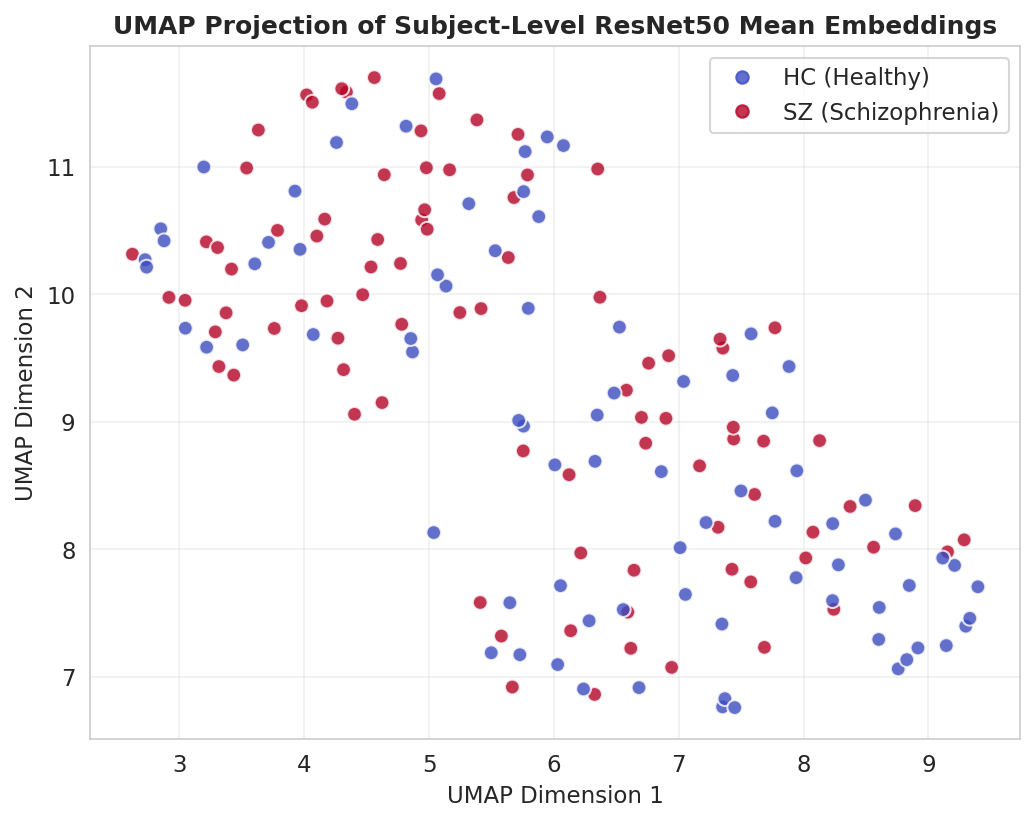

Saved: results/tier4_resnet_umap.png


In [7]:
# 1. UMAP Projection of ResNet50 Subject-Level Mean Embeddings
try:
    from umap import UMAP
    import matplotlib.pyplot as plt
    import numpy as np
    from collections import defaultdict

    print("Running UMAP feature projection...")
    if 'feat_dict' in locals() and feat_dict:
        # 1. Gom nhóm features về cấp đối tượng (homogenize shapes)
        print("Aggregating trial-level features to subject-level mean embeddings...")
        sid_to_label = {}
        if 'df_clean_train' in locals():
            sid_to_label = dict(zip(df_clean_train['Subject_ID'], df_clean_train['Label']))
        else:
            # Fallback nếu chưa load dataframe: 0-103 = SZ, 104-207 = HC
            for (sub_id, _) in feat_dict.keys():
                sid_to_label[sub_id] = 1 if sub_id <= 103 else 0

        subj_vecs = defaultdict(list)
        for (sub_id, img_name), arr in feat_dict.items():
            if arr is not None and len(arr.shape) >= 1:
                # arr shape: [N_fixations, 2048]
                if len(arr.shape) == 1:
                    subj_vecs[sub_id].append(arr)
                else:
                    subj_vecs[sub_id].append(arr.mean(axis=0))

        X_list = []
        labels = []
        for sid, vecs in subj_vecs.items():
            lbl = sid_to_label.get(sid, -1)
            if lbl in [0, 1] and len(vecs) > 0:
                X_list.append(np.mean(vecs, axis=0))
                labels.append(lbl)

        X = np.array(X_list)
        y = np.array(labels)
        print(f"Projecting {X.shape[0]} subjects with dimension {X.shape[1]}...")

        # 2. Chạy UMAP
        reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.15)
        embedding = reducer.fit_transform(X)

        # 3. Vẽ biểu đồ phân tách nhóm đối tượng
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='coolwarm', alpha=0.8, edgecolors='w', s=50)
        plt.title('UMAP Projection of Subject-Level ResNet50 Mean Embeddings', fontsize=12, fontweight='bold')
        plt.xlabel('UMAP Dimension 1')
        plt.ylabel('UMAP Dimension 2')
        plt.legend(handles=scatter.legend_elements()[0], labels=['HC (Healthy)', 'SZ (Schizophrenia)'], loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.savefig(PROJECT_ROOT / 'results' / 'tier4_resnet_umap.png', bbox_inches='tight')
        plt.show()
        print("Saved: results/tier4_resnet_umap.png")
    else:
        print("⚠️ ResNet50 features (feat_dict) không được tìm thấy. Vui lòng chạy cell load trước.")
except ImportError:
    print("⚠️ Thư viện 'umap-learn' chưa được cài đặt. Vui lòng chạy lệnh: !pip install umap-learn")

Plotting decision space separation...


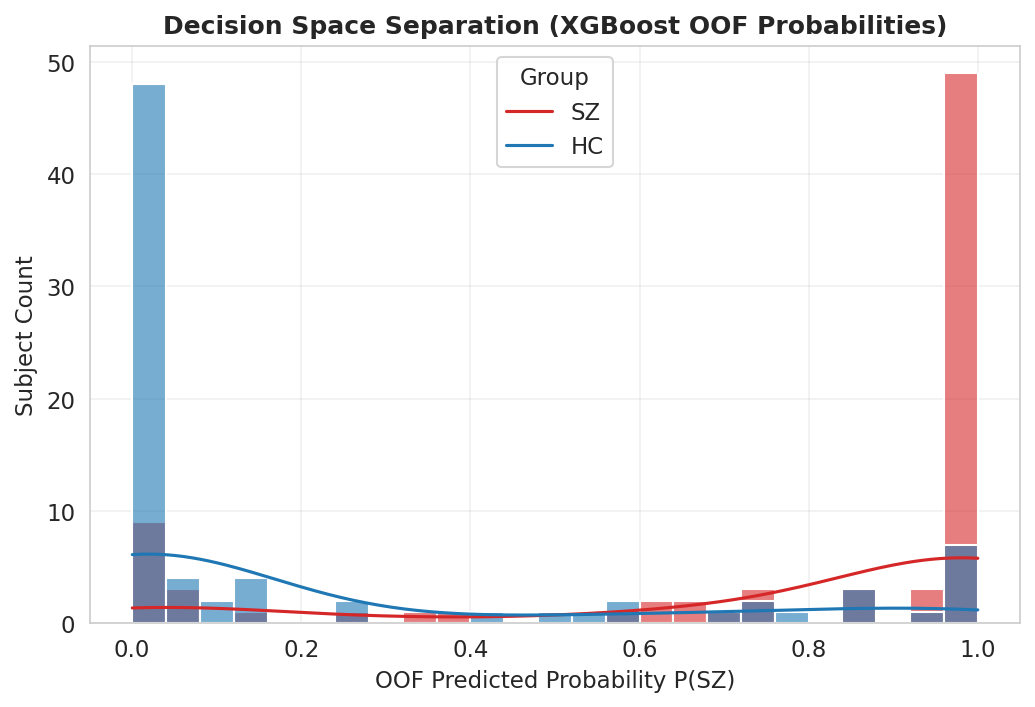

Saved: results/lda_class_separation.png


In [9]:
# 2. GBDT Decision Separation (XGBoost OOF Probabilities)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting decision space separation...")
feature_path = PROJECT_ROOT / 'results' / 'baselines_s42' / 'xgboost_oof_subject_preds.csv'
if feature_path.exists():
    # Đọc dữ liệu OOF predictions của XGBoost
    df_preds = pd.read_csv(feature_path)

    # Cột chứa xác suất dự đoán thực tế là 'Pred_Proba_Subject'
    prob_col = 'Pred_Proba_Subject'

    if prob_col in df_preds.columns:
        plt.figure(figsize=(8, 5))
        # Sử dụng đúng tên cột 'Pred_Proba_Subject'
        sns.histplot(data=df_preds, x=prob_col, hue='Label', kde=True, bins=25, alpha=0.6, palette={0: '#1f77b4', 1: '#d62728'})

        plt.title('Decision Space Separation (XGBoost OOF Probabilities)', fontsize=12, fontweight='bold')
        plt.xlabel('OOF Predicted Probability P(SZ)')
        plt.ylabel('Subject Count')
        plt.legend(title='Group', labels=['SZ', 'HC'])
        plt.grid(True, alpha=0.3)
        plt.savefig(PROJECT_ROOT / 'results' / 'lda_class_separation.png', bbox_inches='tight')
        plt.show()
        print("Saved: results/lda_class_separation.png")
    else:
        print(f"⚠️ Không tìm thấy cột {prob_col} trong file. Các cột hiện có: {list(df_preds.columns)}")
else:
    print("⚠️ Không tìm thấy file OOF predictions. Vui lòng chạy baseline XGBoost trước để tạo lda_class_separation.png.")

Plotting pupil size distribution before and after normalization...
Computing subject-wise standardized pupil sizes...


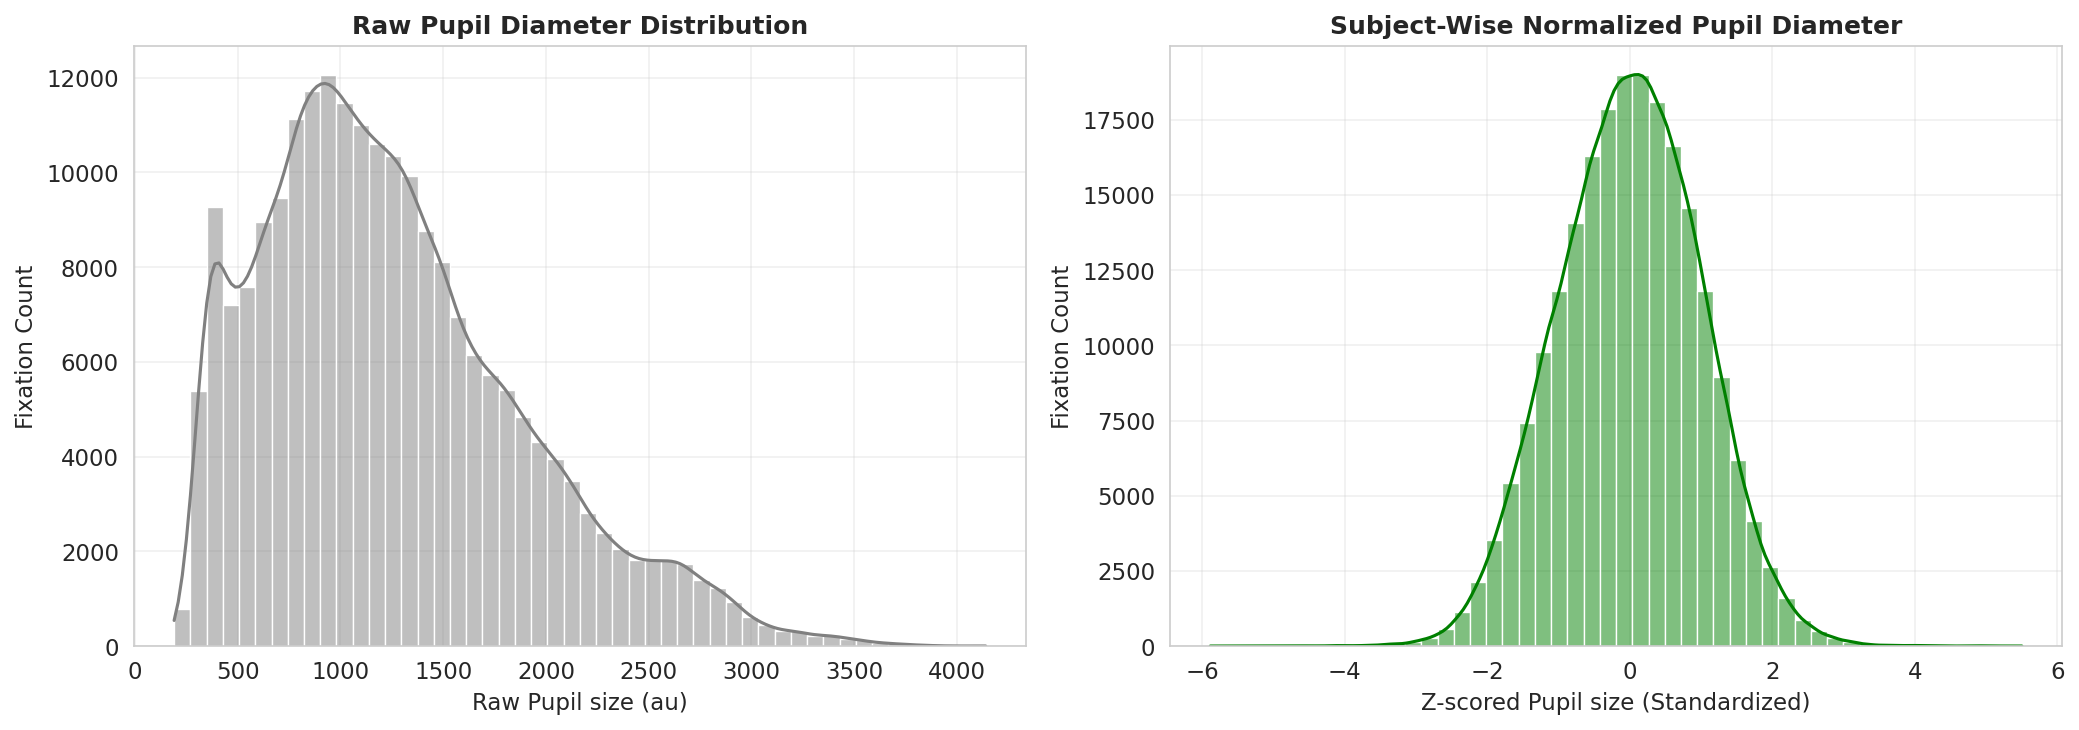

Saved: results/pupil_normalization_comparison.png


In [13]:
# 3. Feature Distribution Before/After Normalization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Plotting pupil size distribution before and after normalization...")

# Tự động gộp hoặc chọn dataframe đang có trong bộ nhớ Colab của bạn
df_to_use = None
if 'df_tr' in locals():
    df_to_use = df_tr
elif 'df_hc' in locals() and 'df_sz' in locals():
    df_to_use = pd.concat([df_hc, df_sz], ignore_index=True)

if df_to_use is not None and 'FIX_PUPIL' in df_to_use.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Vẽ phân phối đồng tử thô (Raw Pupil)
    ax = axes[0]
    sns.histplot(df_to_use['FIX_PUPIL'].dropna(), ax=ax, color='gray', kde=True, bins=50)
    ax.set_title('Raw Pupil Diameter Distribution', fontweight='bold')
    ax.set_xlabel('Raw Pupil size (au)')
    ax.set_ylabel('Fixation Count')
    ax.grid(True, alpha=0.3)

    # 2. Tính toán chuẩn hóa theo từng đối tượng (Subject-wise Z-scoring)
    # Đây là mô phỏng chính xác thuật toán chuẩn hóa đồng tử mà mô hình sử dụng
    print("Computing subject-wise standardized pupil sizes...")
    df_norm = df_to_use.copy()
    subject_stats = df_norm.groupby('Subject_ID')['FIX_PUPIL'].agg(['mean', 'std']).reset_index()
    df_norm = df_norm.merge(subject_stats, on='Subject_ID', suffixes=('', '_stats'))
    df_norm['FIX_PUPIL_NORM'] = (df_norm['FIX_PUPIL'] - df_norm['mean']) / (df_norm['std'] + 1e-8)

    # 3. Vẽ phân phối đồng tử sau khi chuẩn hóa (Normalized Pupil)
    ax = axes[1]
    sns.histplot(df_norm['FIX_PUPIL_NORM'].dropna(), ax=ax, color='green', kde=True, bins=50)
    ax.set_title('Subject-Wise Normalized Pupil Diameter', fontweight='bold')
    ax.set_xlabel('Z-scored Pupil size (Standardized)')
    ax.set_ylabel('Fixation Count')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'results' / 'pupil_normalization_comparison.png', bbox_inches='tight')
    plt.show()
    print("Saved: results/pupil_normalization_comparison.png")
else:
    print("⚠️ Không tìm thấy biến df_tr hoặc cặp biến df_hc/df_sz trong workspace. Vui lòng chạy Section 1 trước.")